## Random

In [ ]:
import numpy as np
from lsst.afw.image import ExposureF
from lsst.geom import Point2D
from xlens.utils.image import resize_array

In [ ]:
hdul.info()

In [ ]:
hdul[1].data['gamma1']

## Phase 1: Load Blended Exposure & PSF

Load the DC1 blended simulation FITS file, extract the science image, truth catalog, and PSF.

Image shape: (1500, 1500)
Truth objects: 62794
Objects inside exposure: 5908
cat_ref objects: 858502
PSF shape: (48, 48)
Noise sigma from variance: 0.5950
Position range: x=[0.10, 1499.91], y=[0.22, 1499.81]


,indices,redshift,angles,gamma1,gamma2,kappa,dx,dy,ra,dec,...,b_d,pa_bulge,pa_disk,u_ab,g_ab,r_ab,i_ab,z_ab,y_ab,prob
0,281842,1.576306,0.510737,-0.02,0.0,0.0,-392.287942,-166.924957,0.108941,-0.046340,...,0.122653,279.685822,279.685822,25.665459,25.682413,25.702526,25.497686,25.278593,24.882441,1.017127
1,183329,2.373513,6.159579,-0.02,0.0,0.0,-340.990896,-271.419525,0.094692,-0.075366,...,0.184073,0.000000,83.929153,27.582075,27.378025,27.398834,27.497972,27.483135,27.424690,1.017127
2,384236,1.762110,1.637001,-0.02,0.0,0.0,-431.781155,-427.815589,0.119911,-0.118809,...,0.062699,0.000000,226.936813,27.416513,27.373596,27.515270,27.400213,27.288643,27.160473,1.017127
3,856121,2.463449,0.378942,-0.02,0.0,0.0,-194.436491,-222.304176,0.053982,-0.061723,...,0.050474,0.000000,165.086105,28.533834,27.490349,27.375641,27.798340,27.493877,27.351936,1.017127
4,57392,0.453580,0.559692,-0.02,0.0,0.0,-166.277145,-284.224165,0.046160,-0.078923,...,0.103772,0.000000,299.087799,29.608217,27.581324,26.178127,25.528465,25.189220,25.005207,1.017127


Selected 50 objects: i_ab=[17.978, 21.600]


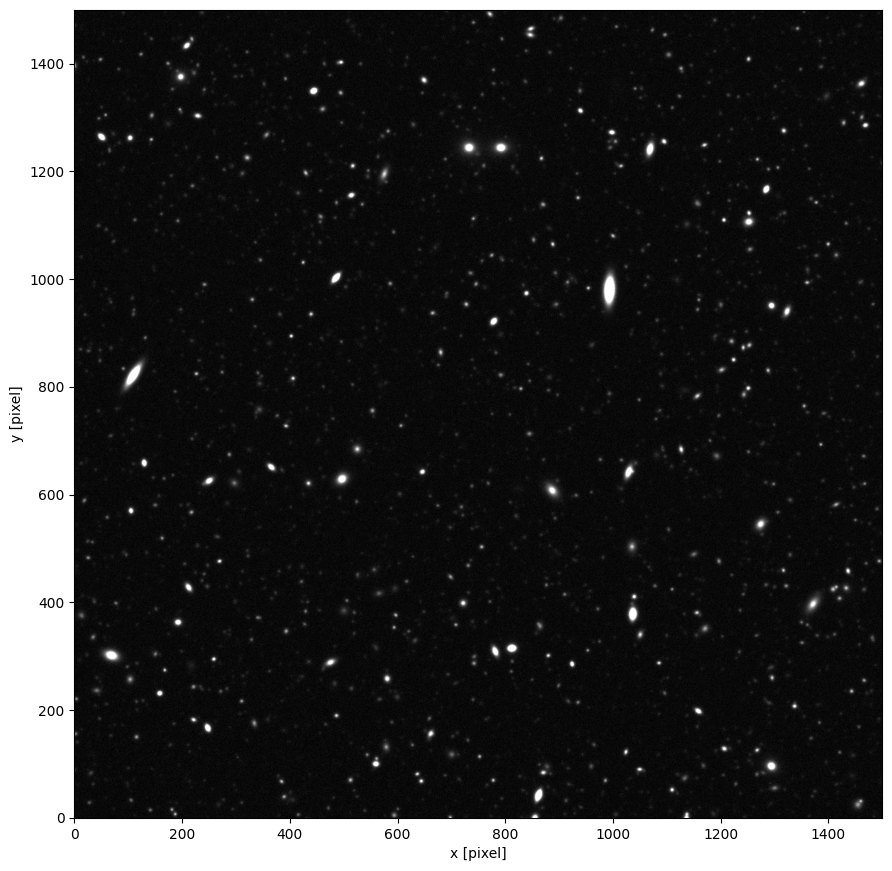

,indices,x,y,i_ab,redshift,hlr
4790,295608,994.354055,980.510520,17.978304,0.057359,1.380152e+00
2332,796810,110.719088,822.326702,18.737820,0.222713,1.287801e+00
1216,275752,1037.804666,378.968870,19.244263,0.169143,6.308511e-01
4377,677838,862.694062,42.737995,19.378925,0.317265,4.491336e-01
5146,841594,813.185604,315.586519,19.462517,0.190841,2.654856e-01
5603,857900,733.811930,1244.608096,19.572918,0.793341,1.000000e-09
4854,532332,792.975256,1244.622742,19.575626,0.388855,1.000000e-09
5358,794683,70.165756,302.434600,19.626104,0.354353,1.259248e+00
1795,338515,486.859847,1003.118094,19.833096,0.416452,4.844618e-01
4741,189580,1294.855366,97.005862,19.851303,0.464242,1.000000e-09


In [2]:
import os
import sys
sys.path.insert(0, "/projects/bdsp/wenyinli/codes/single_galaxies")

import fitsio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits


# ---------- Parameters ----------

FITS_PATH = "/taiga/illinois/las/astro/xinliuxl/DC1_sim_blended/sim_mode0/exp-i-00001.fits"
TRUTH_PATH = "/taiga/illinois/las/astro/xinliuxl/DC1_sim_blended/sim_mode0/truth-00001.fits"
CAT_REF_PATH = "/projects/bdsp/wenyinli/codes/data/catsim-v4/OneDegSq.fits"

PIXEL_SCALE = 0.2
NOISE_LEVEL = 0.3


def native_column(array):
    """Convert FITS arrays to native byte order for pandas."""
    array = np.asarray(array)
    array = array.astype(array.dtype.newbyteorder("="), copy=False)
    return array if array.ndim == 1 else list(array)


# ---------- Load exposure ----------

with fits.open(FITS_PATH, memmap=False) as hdul:
    large_image = np.asarray(hdul[1].data, dtype=np.float64)
    variance_map = np.asarray(hdul[3].data, dtype=np.float64)

ny, nx = large_image.shape


# ---------- Load truth and reference catalogs ----------

with fits.open(TRUTH_PATH, memmap=False) as hdul:
    truth_raw = hdul[1].data.copy()

cat_ref = fitsio.read(CAT_REF_PATH)

truth_df = pd.DataFrame({
    name: native_column(truth_raw[name])
    for name in truth_raw.dtype.names
})


# ---------- Convert dx/dy to image pixels ----------

x_all = nx / 2 + truth_df["dx"].to_numpy(dtype=float) / PIXEL_SCALE+1500
y_all = ny / 2 + truth_df["dy"].to_numpy(dtype=float) / PIXEL_SCALE+1500

inside = (
    (x_all >= 0) & (x_all < nx)
    & (y_all >= 0) & (y_all < ny)
)

cat = truth_df.loc[inside].reset_index(drop=True)
cat["x"] = x_all[inside]
cat["y"] = y_all[inside]
cat["e1"] = cat["gamma1"]
cat["e2"] = cat["gamma2"]


# ---------- Add matching rows from cat_ref ----------

# truth catalog indices are row numbers in cat_ref
ref_indices = cat["indices"].to_numpy(dtype=np.int64)

if ref_indices.min() < 0 or ref_indices.max() >= len(cat_ref):
    raise IndexError(
        f"indices range [{ref_indices.min()}, {ref_indices.max()}] "
        f"is outside cat_ref range [0, {len(cat_ref) - 1}]"
    )

cat_ref_selected = cat_ref[ref_indices]

for name in cat_ref_selected.dtype.names:
    # Avoid overwriting truth columns with the same name
    output_name = name if name not in cat.columns else f"{name}_ref"
    cat[output_name] = native_column(cat_ref_selected[name])


# Downstream convention: (y, x)
positions = cat[["y", "x"]].to_numpy(dtype=np.float64)


# ---------- Load PSF ----------

psf_image = np.load("./logs/blended_test_psf.npy").astype(np.float64)[1:,1:]


# ---------- Noise ----------

valid_variance = variance_map[
    np.isfinite(variance_map) & (variance_map > 0)
]

noise_from_variance = np.sqrt(np.median(valid_variance))
noise_levels = np.full(len(cat), NOISE_LEVEL, dtype=np.float64)
canvas_size = ny


# ---------- Summary ----------

print(f"Image shape: {large_image.shape}")
print(f"Truth objects: {len(truth_raw)}")
print(f"Objects inside exposure: {len(cat)}")
print(f"cat_ref objects: {len(cat_ref)}")
print(f"PSF shape: {psf_image.shape}")
print(f"Noise sigma from variance: {noise_from_variance:.4f}")
print(
    f"Position range: "
    f"x=[{cat['x'].min():.2f}, {cat['x'].max():.2f}], "
    f"y=[{cat['y'].min():.2f}, {cat['y'].max():.2f}]"
)

display(cat.head())


# ---------- Plot ----------

# ---------- Plot 50 objects with the smallest i_ab ----------

brightest_50 = (
    cat.loc[np.isfinite(cat["i_ab"])]
    .nsmallest(50, "i_ab")
    .copy()
)

print(
    f"Selected {len(brightest_50)} objects: "
    f"i_ab=[{brightest_50['i_ab'].min():.3f}, "
    f"{brightest_50['i_ab'].max():.3f}]"
)

vmin, vmax = np.nanpercentile(large_image, [5, 99.8])

plt.figure(figsize=(9, 9))

plt.imshow(
    large_image,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

'''plt.scatter(
    brightest_50["x"],
    brightest_50["y"],
    s=100,
    facecolors="none",
    edgecolors="red",
    linewidths=1.2,
)'''

plt.xlim(0, nx)
plt.ylim(0, ny)
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
#plt.title("50 objects with the smallest $i_{AB}$")

plt.tight_layout()
plt.show()

display(
    brightest_50[
        ["indices", "x", "y", "i_ab", "redshift", "hlr"]
    ].sort_values("i_ab")
)

### Setup: create noise-free alias for downstream compatibility

In [8]:
# ---- For blended images, "noise-free" = same image ----
# The original pipeline had separate noise-free data for debugging.
# For blended data, we just use the same image under both names.
large_nn = large_image
psf_nn = psf_image
pos_nn = positions
cat_nn = cat
cs_nn = canvas_size  # canvas_size alias
noise_nn = noise_levels

print(f"large_nn is large_image: {large_nn is large_image}")
print(f"Ready for Phase 2+3 pipeline (both noisy and 'noise-free' paths).")

large_nn is large_image: True
Ready for Phase 2+3 pipeline (both noisy and 'noise-free' paths).


## Phase 2: FPFS Detection — Run anacal detection on the blended image

In [9]:
# ---- Phase 2: Setup FPFS config and import detection function ----
import anacal
from src.anacal.detection_ml_pipeline import run_fpfs_detection

# FPFS configuration (same as used in fpfs.py)
fpfs_config = anacal.fpfs.FpfsConfig(
    sigma_shapelets=0.52,    # detection scale
    sigma_shapelets1=0.45,   # measurement scale 1
    sigma_shapelets2=0.55,   # measurement scale 2
)

# Noise variance: use median of variance map if available, else fixed
if 'variance_map' in dir() and variance_map is not None:
    noise_variance = float(np.median(variance_map[variance_map > 0]))
else:
    noise_variance = NOISE_LEVEL**2 if NOISE_LEVEL > 0 else 1e-4

print(f"noise_variance = {noise_variance:.2e}")
print(f"FPFS config: sigma_as=0.52, sigma1=0.45, sigma2=0.55")

noise_variance = 3.54e-01
FPFS config: sigma_as=0.52, sigma1=0.45, sigma2=0.55


In [21]:
# ---- Run FPFS detection on the blended image ----
print("Running FPFS detection on blended image...")
print(f"Image shape: {large_image.shape}, PSF shape: {psf_image.shape}")

noise_array = np.random.randn(ny, nx) * np.sqrt(noise_variance)

det_cat = run_fpfs_detection(
    large_image=large_image,
    psf_image=psf_image,
    fpfs_config=fpfs_config,
    mag_zero=30.0,
    pixel_scale=0.2,
    noise_variance=noise_variance,
    noise_array=noise_array,          # externally generated re-noise
)

# ---- Weight filter (to match blended_run.py behavior) ----
if len(det_cat) > 0:
    keep = det_cat["fpfs_w"] >= 1e-6
    print(f"Weight filter: {np.sum(keep)}/{len(det_cat)} pass fpfs_w >= 1e-6")
    det_cat = det_cat[keep]

print(f"\nDetection complete!")
print(f"Number of detections: {len(det_cat)}")
print(f"Detection catalog dtype names: {det_cat.dtype.names}")

if len(det_cat) > 0:
    print(f"\nFirst 5 detections:")
    for name in det_cat.dtype.names:
        print(f"  {name}: {det_cat[name][:5]}")
else:
    print("WARNING: No objects detected! Check:")
    print("  - Is the image non-empty?")
    print("  - Is noise_variance set correctly?")
    print("  - Try adjusting sigma_arcsec for detection.")


Running FPFS detection on blended image...
Image shape: (1500, 1500), PSF shape: (48, 48)
Weight filter: 1457/1717 pass fpfs_w >= 1e-6

Detection complete!
Number of detections: 1457
Detection catalog dtype names: ('det_id', 'y', 'x', 'fpfs_e1', 'fpfs_e2', 'fpfs_R11', 'fpfs_R22', 'fpfs_w', 'fpfs_dw_dg1', 'fpfs_dw_dg2', 'fpfs_m00', 'fpfs_dm00_dg1', 'fpfs_dm00_dg2')

First 5 detections:
  det_id: [0 1 3 5 6]
  y: [41. 49. 53. 62. 64.]
  x: [391. 403. 302. 298. 100.]
  fpfs_e1: [ 0.01097716 -0.10492814 -0.0520977   0.10959302 -0.30439853]
  fpfs_e2: [ 0.04379633  0.07408878  0.11693821  0.08086687 -0.14258634]
  fpfs_R11: [ 0.28158868  0.67454636  0.04961083 -0.28920801  0.24590319]
  fpfs_R22: [ 0.26798351  0.27749578 -0.80278669  0.64053139  0.28094777]
  fpfs_w: [1. 1. 1. 1. 1.]
  fpfs_dw_dg1: [0. 0. 0. 0. 0.]
  fpfs_dw_dg2: [0. 0. 0. 0. 0.]
  fpfs_m00: [586.43523713 129.99920543  58.22645488  82.55591129 101.27466929]
  fpfs_dm00_dg1: [10.02480704 32.59227536 -9.45125754 22.00909322 3

KDTree match (r<=5.0px): N_det=1457  N_matched=1452  (99.7%)
mag_i < 24.5: N_det=575  N_matched=575  precision=1.000
Accuracy (bright+matched, N=575):
  bias  e1=+0.0153  e2=+0.0006
  RMS   e1=0.0901  e2=0.0906


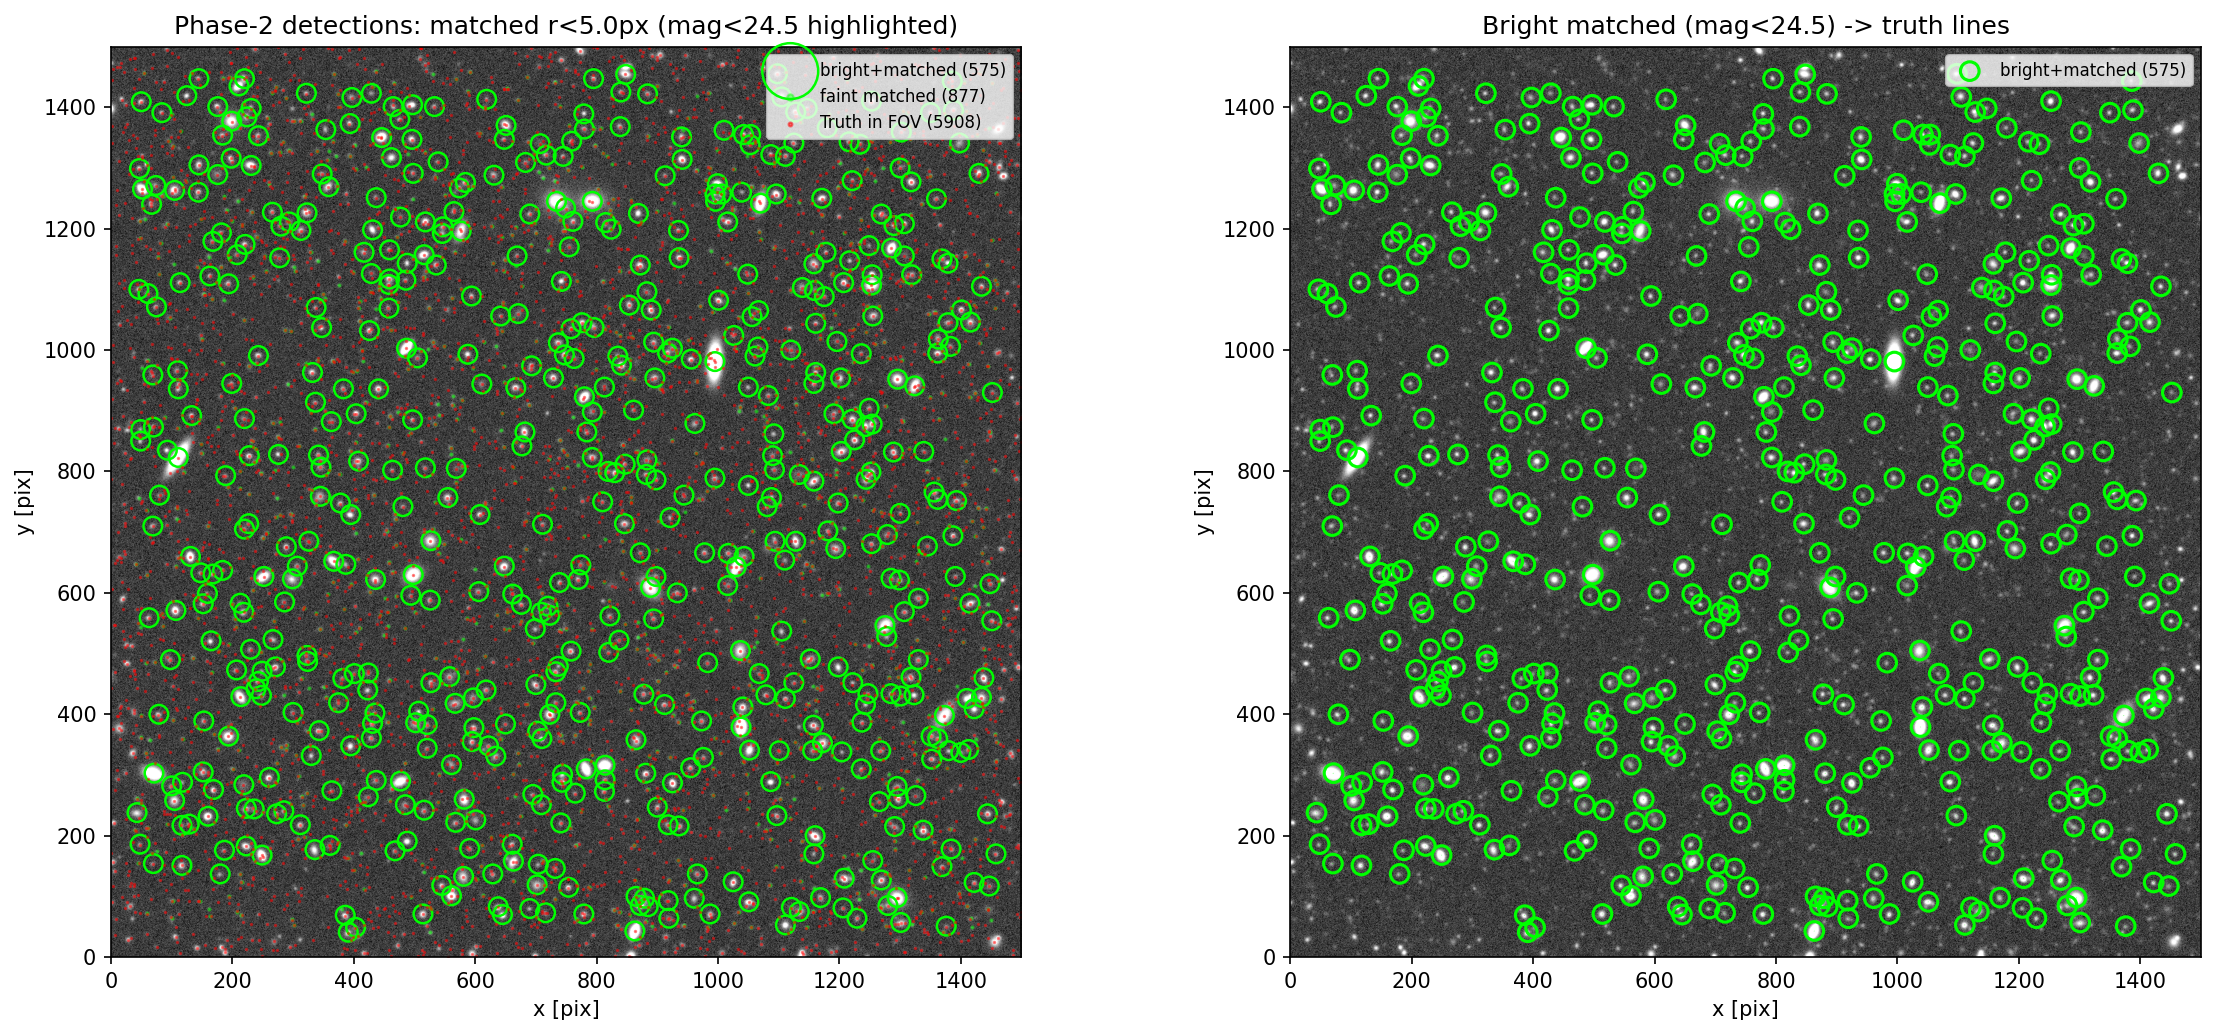


=== Summary ===
  Total detections:                1457
  Matched (r<5.0px):          1452  (99.7%)
  Bright (mag<24.5):             575
  Bright + matched:                575
  Precision (bright):              1.0000
  Bias (bright+matched):           e1=+0.0153  e2=+0.0006
  RMS  (bright+matched):           e1=0.0901  e2=0.0906


In [22]:
# ---- Detection validation: KDTree re-match, mag-cut precision & accuracy ----
# Re-matches det_cat to truth (5 px), filters mag_i<24.5,
# plots only matched detections, and reports precision/accuracy.

MATCH_R = 5.0
MAG_CUT = 24.5

import numpy as np
import fitsio
from scipy.spatial import cKDTree

# ===== 1. Build truth positions for this exposure =====
# (truth_raw + positions from Phase 1 are already loaded)
truth_pts_all = np.column_stack([
    ny/2 + truth_raw["dy"].astype(np.float64)/PIXEL_SCALE + X_OFFSET,
    nx/2 + truth_raw["dx"].astype(np.float64)/PIXEL_SCALE + X_OFFSET,
])   # (y, x)

# ===== 2. KDTree match detections -> truth =====
tree = cKDTree(truth_pts_all)
det_pts = np.column_stack([det_cat["y"], det_cat["x"]])
distances, indices = tree.query(det_pts, k=1)

match_mask = distances <= MATCH_R
match_tidx = np.where(match_mask, indices, -1)
match_dist = np.where(match_mask, distances, 999.0)
n_det = len(det_cat)
n_matched = int(np.sum(match_mask))
print(f"KDTree match (r<={MATCH_R}px): N_det={n_det}  N_matched={n_matched}  ({100*n_matched/max(n_det,1):.1f}%)")

# ===== 3. Get mag_i from cat_ref for matched truth =====
# truth_raw["indices"] -> row in cat_ref
cat_ref = fitsio.read(CAT_REF_PATH)
mag_i_all = np.full(len(det_cat), np.nan)
if n_matched > 0:
    ref_idx = truth_raw["indices"][match_tidx[match_mask]]
    mag_i_all[match_mask] = cat_ref["i_ab"][ref_idx]

bright_mask = np.isfinite(mag_i_all) & (mag_i_all < MAG_CUT)
n_bright = int(np.sum(bright_mask))
n_bright_matched = int(np.sum(bright_mask & match_mask))

precision = n_bright_matched / max(n_bright, 1)
print(f"mag_i < {MAG_CUT}: N_det={n_bright}  N_matched={n_bright_matched}  "
      f"precision={precision:.3f}")

# ===== 4. Accuracy: bias of FPFS vs truth for bright+matched =====
valid = bright_mask & match_mask
if np.sum(valid) > 0:
    fpfs_e1 = det_cat["fpfs_e1"][valid]
    fpfs_e2 = det_cat["fpfs_e2"][valid]
    # truth ellipticities from truth_raw
    t_e1 = truth_raw["gamma1"][match_tidx[valid]]
    t_e2 = truth_raw["gamma2"][match_tidx[valid]]
    de1 = fpfs_e1 - t_e1
    de2 = fpfs_e2 - t_e2
    bias_e1 = np.mean(de1)
    bias_e2 = np.mean(de2)
    rms_e1 = np.sqrt(np.mean(de1**2))
    rms_e2 = np.sqrt(np.mean(de2**2))
    print(f"Accuracy (bright+matched, N={np.sum(valid)}):")
    print(f"  bias  e1={bias_e1:+.4f}  e2={bias_e2:+.4f}")
    print(f"  RMS   e1={rms_e1:.4f}  e2={rms_e2:.4f}")
else:
    bias_e1 = bias_e2 = rms_e1 = rms_e2 = np.nan
    print("No bright+matched detections for accuracy.")

# ===== 5. Plot: matched only + truth (mag-cut highlighted) =====
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)
vmin, vmax = np.nanpercentile(large_image, [2, 99.5])
lvmin = np.log(vmin - large_image.min() + 0.001)
lvmax = np.log(vmax - large_image.min() + 0.001)

# Left: matched detections (green) + unmatched (grey dots)
ax = axes[0]
ax.imshow(np.log(large_image - large_image.min() + 0.001), origin="lower",
          cmap="gray", vmin=lvmin, vmax=lvmax)
if n_matched > 0:
    # bright+matched = lime, bright+unmatched = orange
    bm = bright_mask & match_mask
    bu = bright_mask & ~match_mask
    if np.sum(bm) > 0:
        ax.scatter(det_cat["x"][bm], det_cat["y"][bm], marker="o",
                   facecolors="none", edgecolors="lime", s=80, linewidths=1.2,
                   label=f"bright+matched ({np.sum(bm)})")
    if np.sum(bu) > 0:
        ax.scatter(det_cat["x"][bu], det_cat["y"][bu], marker="o",
                   facecolors="none", edgecolors="orange", s=40, linewidths=0.8,
                   alpha=0.7, label=f"bright un-matched ({np.sum(bu)})")
    # faint matched
    fm = ~bright_mask & match_mask
    if np.sum(fm) > 0:
        ax.scatter(det_cat["x"][fm], det_cat["y"][fm], marker=".",
                   color="lime", s=4, alpha=0.4, label=f"faint matched ({np.sum(fm)})")
# truth in FOV
inside_fov = (truth_pts_all[:,1]>=0) & (truth_pts_all[:,1]<nx) & (truth_pts_all[:,0]>=0) & (truth_pts_all[:,0]<ny)
idx_fov = np.where(inside_fov)[0]
n_show = min(5000, len(idx_fov))
ax.scatter(truth_pts_all[idx_fov[:n_show], 1], truth_pts_all[idx_fov[:n_show], 0],
           marker=".", color="red", s=1.5, alpha=0.5,
           label=f"Truth in FOV ({int(np.sum(inside_fov))})")
ax.set(xlim=(0, nx), ylim=(0, ny), xlabel="x [pix]", ylabel="y [pix]",
       title=f"Phase-2 detections: matched r<{MATCH_R}px (mag<{MAG_CUT} highlighted)")
ax.legend(fontsize=8, markerscale=3, loc="upper right")

# Right: bright+matched only + lines to truth
ax = axes[1]
ax.imshow(np.log(large_image - large_image.min() + 0.001), origin="lower",
          cmap="gray", vmin=lvmin, vmax=lvmax)
if np.sum(bm) > 0:
    mx = det_cat["x"][bm]; my = det_cat["y"][bm]
    mtx = truth_pts_all[match_tidx[bm], 1]
    mty = truth_pts_all[match_tidx[bm], 0]
    ax.scatter(mx, my, marker="o", facecolors="none", edgecolors="lime",
               s=80, linewidths=1.5, label=f"bright+matched ({np.sum(bm)})")
    for k in range(min(np.sum(bm), 200)):
        ax.plot([mx[k], mtx[k]], [my[k], mty[k]], "lime", lw=0.3, alpha=0.5)
ax.set(xlim=(0, nx), ylim=(0, ny), xlabel="x [pix]", ylabel="y [pix]",
       title=f"Bright matched (mag<{MAG_CUT}) -> truth lines")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

print(f"\n=== Summary ===")
print(f"  Total detections:                {n_det}")
print(f"  Matched (r<{MATCH_R}px):          {n_matched}  ({100*n_matched/max(n_det,1):.1f}%)")
print(f"  Bright (mag<{MAG_CUT}):             {n_bright}")
print(f"  Bright + matched:                {n_bright_matched}")
print(f"  Precision (bright):              {precision:.4f}")
print(f"  Bias (bright+matched):           e1={bias_e1:+.4f}  e2={bias_e2:+.4f}")
print(f"  RMS  (bright+matched):           e1={rms_e1:.4f}  e2={rms_e2:.4f}")


## Phase 3: Cut Stamps + ML Shape Measurement

In [9]:
# ---- Phase 3a: Load ML model + setup Calibrator ----
import torch
from src.anacal.batch_calibration import Calibrator
from src.architecture.forward8_CNN import Forward8_fixW_CNN
from src.anacal.detection_ml_pipeline import cut_stamps_from_large
from src.blending.ml_shape_measurement import ml_shape_measure, run_ml_on_detections

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the FPFS-trained model (same as shape_measurement.py)
MODEL_PATH = "./models/F8_fpfs_l5c32r01_50ep.pth"
model = Forward8_fixW_CNN(num_layers=5, base_channels=32, res_factor=0.1).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
print(f"Model loaded from {MODEL_PATH}")

# Setup calibrator (wraps model with response computation)
calibrator = Calibrator(model, device=device, dtype="float32")
print("Calibrator ready.")

Using device: cuda
Model loaded from ./models/F8_fpfs_l5c32r01_50ep.pth
Calibrator ready.


mag_i < 24.5: N=587  (matched=587, unmatched=0)


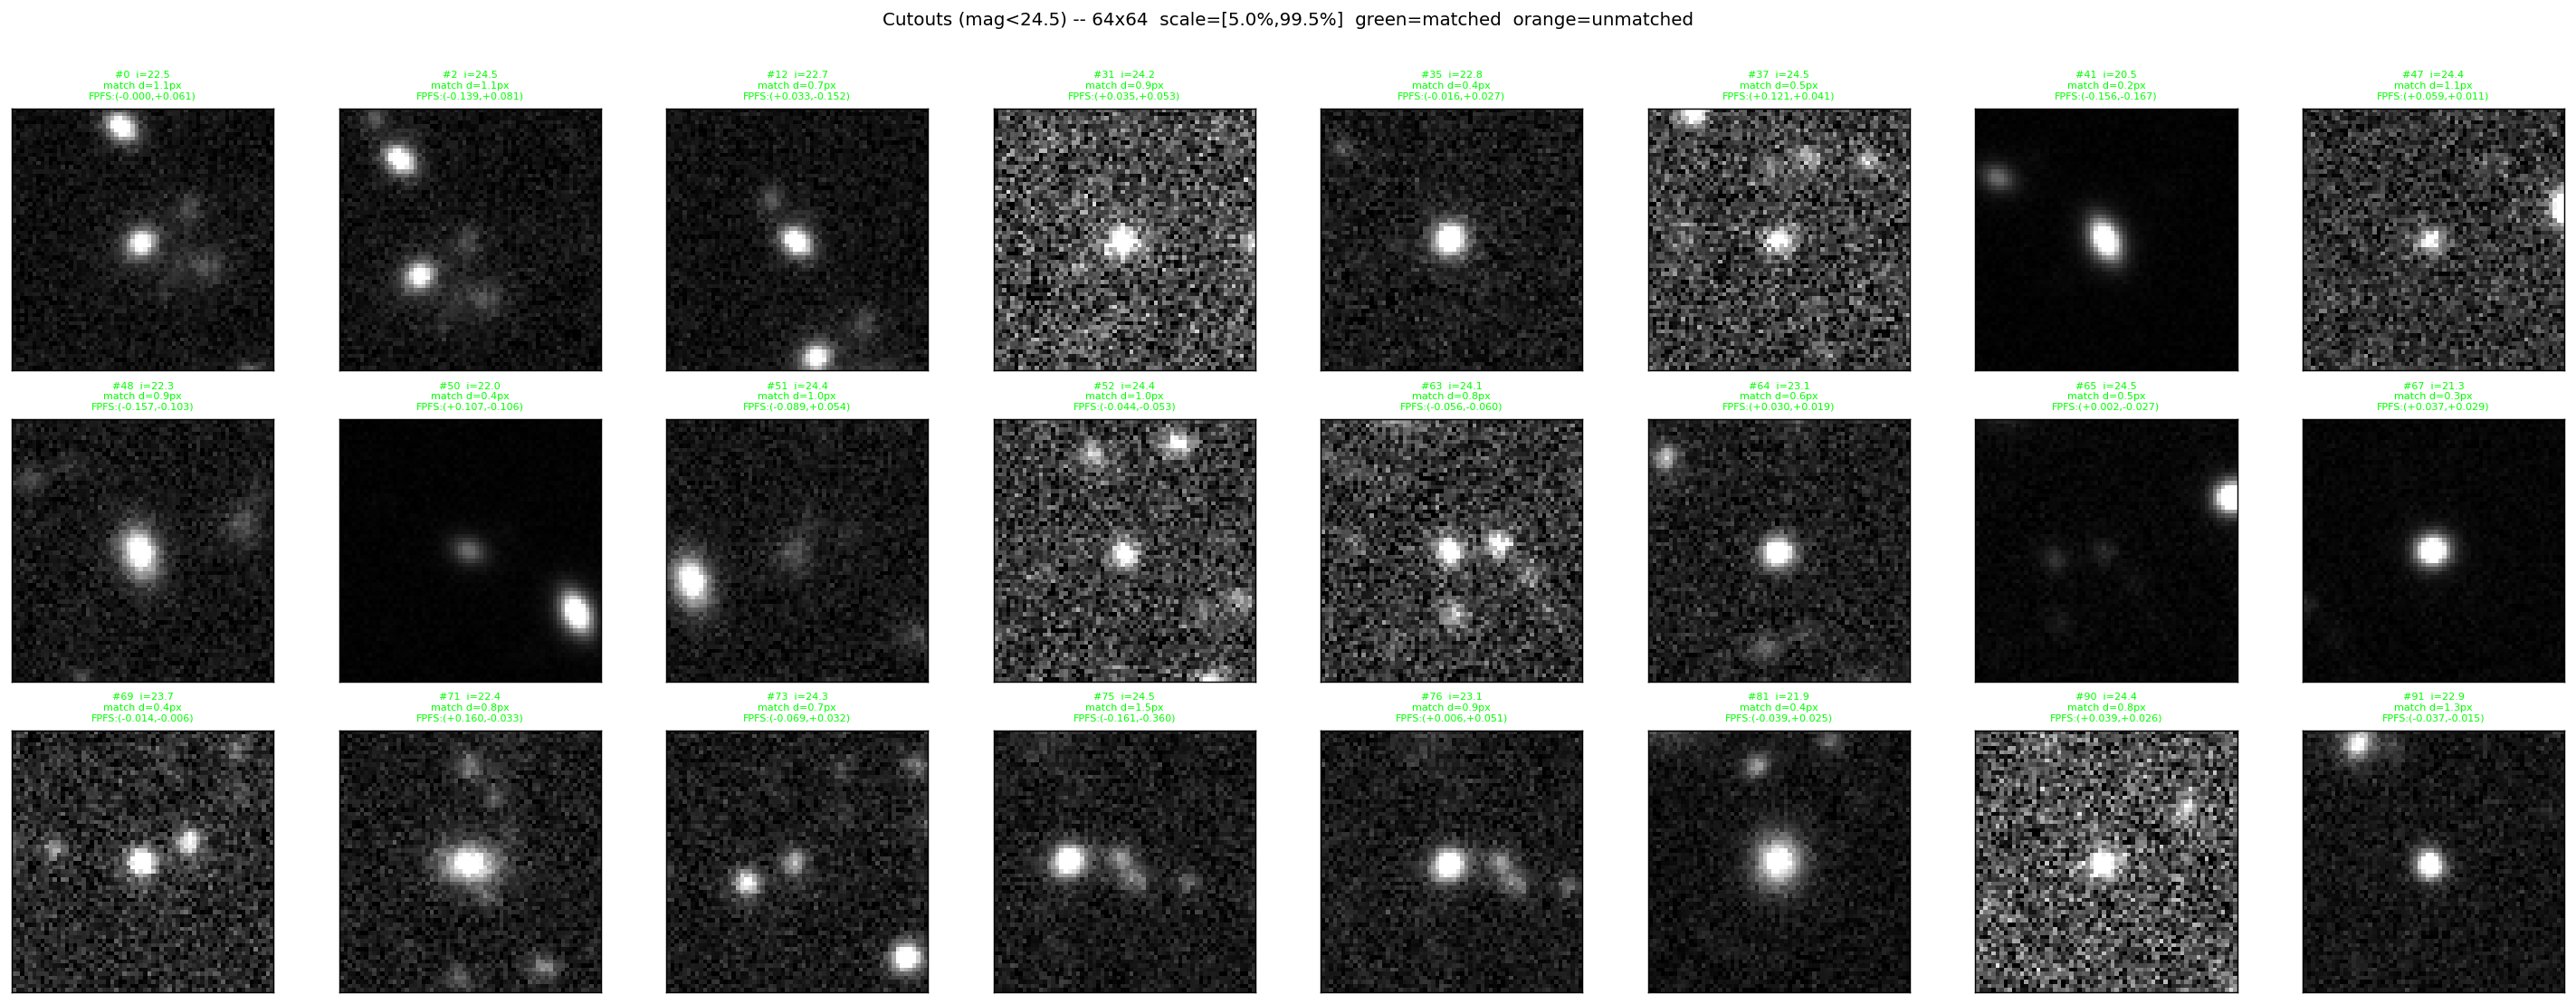

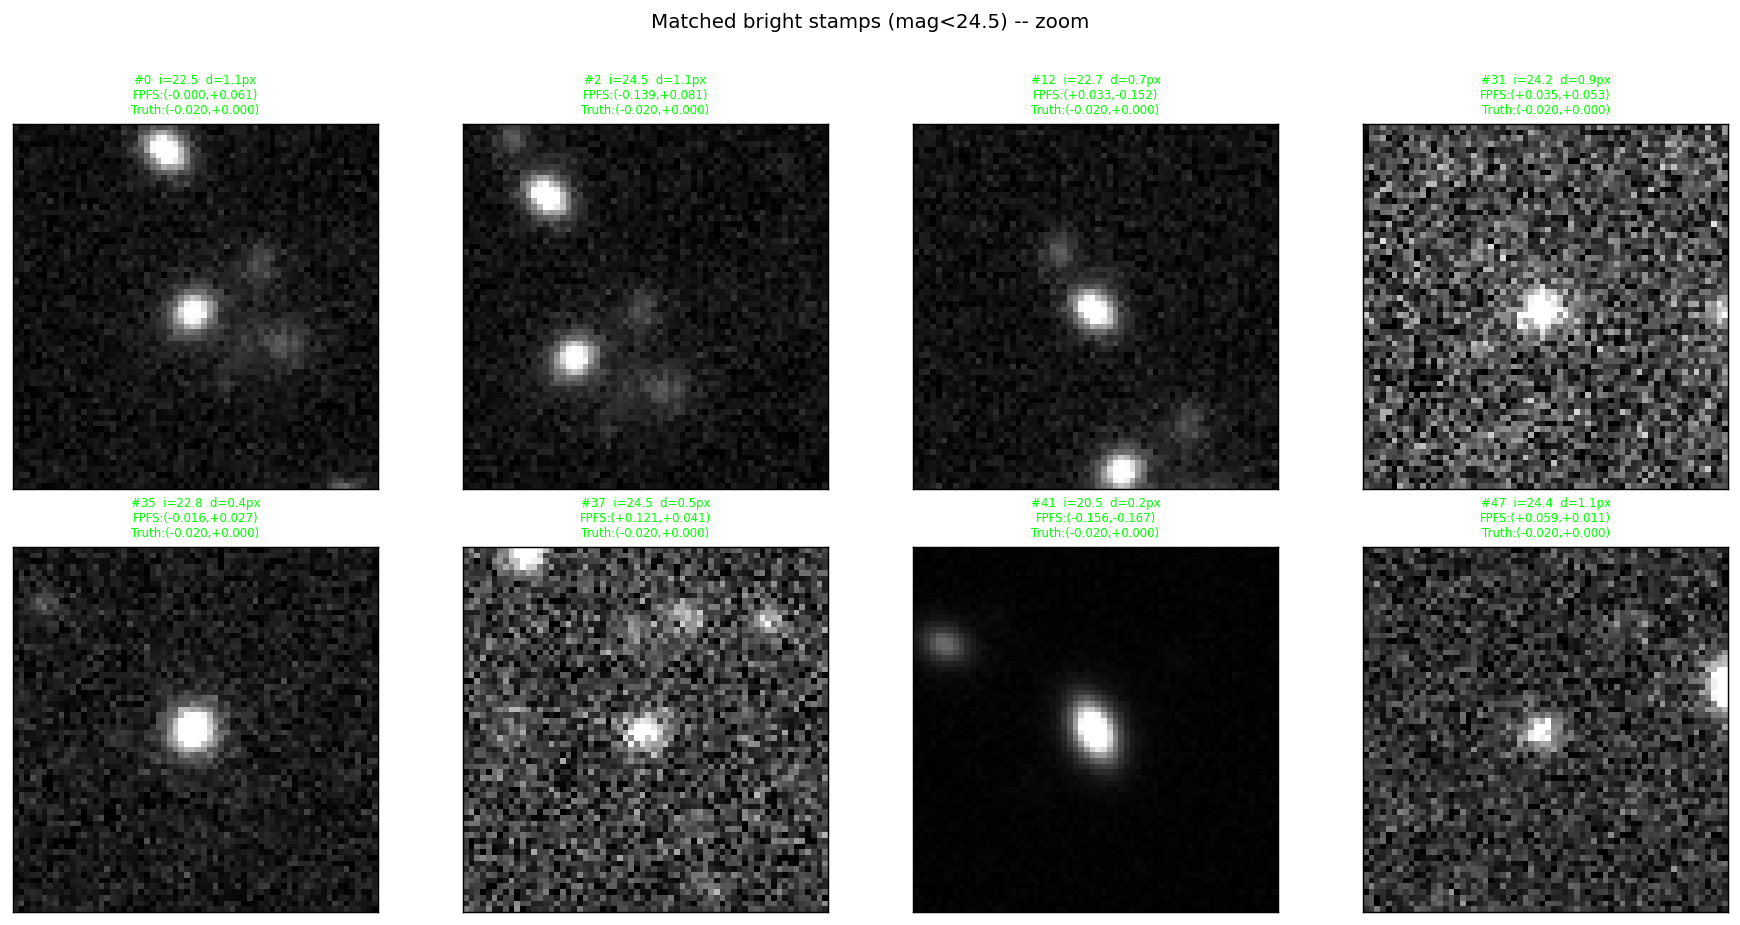

In [17]:
# ---- Phase 3b: Cutout stamp examples (mag<24.5, better rescale) ----
# Cuts 64x64 stamps around Phase-2 detections from large_image.
# Shows only bright detections (mag_i<24.5), uses percentile rescaling
# to highlight the central galaxy.

import numpy as np
import fitsio
import matplotlib.pyplot as plt

# ===== Parameters =====
STAMP_SIZE = 64
MAG_CUT = 24.5
N_SHOW = 24
NCOLS = 8
VLO, VHI = 5.0, 99.5    # percentile range for display scaling

half = STAMP_SIZE // 2
H, W = large_image.shape

yc = np.floor(det_cat["y"] + 0.5).astype(np.int32)
xc = np.floor(det_cat["x"] + 0.5).astype(np.int32)

# ===== 1. Build truth positions & KDTree match (if not already done) =====
truth_pts_all = np.column_stack([
    ny/2 + truth_raw["dy"].astype(np.float64)/PIXEL_SCALE + X_OFFSET,
    nx/2 + truth_raw["dx"].astype(np.float64)/PIXEL_SCALE + X_OFFSET,
])

from scipy.spatial import cKDTree
tree = cKDTree(truth_pts_all)
det_pts = np.column_stack([det_cat["y"], det_cat["x"]])
distances, indices = tree.query(det_pts, k=1)
match_mask = distances <= MATCH_R if 'MATCH_R' in dir() else distances <= 5.0
match_tidx = np.where(match_mask, indices, -1)
match_dist = np.where(match_mask, distances, 999.0)

# ===== 2. Get mag_i from cat_ref =====
cat_ref = fitsio.read(CAT_REF_PATH)
mag_i_all = np.full(len(det_cat), np.nan)
matched = match_mask
if np.sum(matched) > 0:
    ref_idx = truth_raw["indices"][match_tidx[matched]]
    mag_i_all[matched] = cat_ref["i_ab"][ref_idx]

bright_mask = np.isfinite(mag_i_all) & (mag_i_all < MAG_CUT)
print(f"mag_i < {MAG_CUT}: N={np.sum(bright_mask)}  "
      f"(matched={np.sum(bright_mask & match_mask)}, "
      f"unmatched={np.sum(bright_mask & ~match_mask)})")

# ===== 3. Pick examples: bright matched first, then bright unmatched =====
bm_idx = np.where(bright_mask & match_mask)[0]
bu_idx = np.where(bright_mask & ~match_mask)[0]
show_idx = list(bm_idx[:N_SHOW]) + list(bu_idx[:N_SHOW - len(bm_idx[:N_SHOW])])
show_idx = np.array(show_idx[:N_SHOW])

if len(show_idx) == 0:
    print("No bright detections to show!")
else:
    nrows = int(np.ceil(len(show_idx) / NCOLS))
    fig, axes = plt.subplots(nrows, NCOLS, figsize=(2.8*NCOLS, 2.8*nrows), dpi=130)
    axes = axes.flatten() if len(show_idx) > 1 else [axes]

    for k, i_det in enumerate(show_idx):
        y1 = max(yc[i_det] - half, 0); y2 = min(yc[i_det] + half, H)
        x1 = max(xc[i_det] - half, 0); x2 = min(xc[i_det] + half, W)
        ax = axes[k]
        stamp = large_image[y1:y2, x1:x2]

        # ---- Percentile-based rescale: clip extreme pixels ----
        vlo, vhi = np.nanpercentile(stamp, [VLO, VHI])
        ax.imshow(stamp, origin="lower", cmap="gray", vmin=vlo, vmax=vhi)
        ax.set_xticks([]); ax.set_yticks([])

        is_m = match_mask[i_det]
        color = "lime" if is_m else "orange"
        fpfs_e1 = det_cat["fpfs_e1"][i_det]
        fpfs_e2 = det_cat["fpfs_e2"][i_det]
        mag_i = mag_i_all[i_det]
        title = f"#{i_det}  i={mag_i:.1f}"
        if is_m:
            title += f"\nmatch d={match_dist[i_det]:.1f}px"
        else:
            title += "\n(unmatched)"
        title += f"\nFPFS:({fpfs_e1:+.3f},{fpfs_e2:+.3f})"
        ax.set_title(title, fontsize=6.2, color=color)

    for k in range(len(show_idx), len(axes)):
        axes[k].axis("off")

    plt.suptitle(f"Cutouts (mag<{MAG_CUT}) -- {STAMP_SIZE}x{STAMP_SIZE}  "
                 f"scale=[{VLO}%,{VHI}%]  green=matched  orange=unmatched",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

# ===== 4. Zoom on matched bright stamps (with FPFS + truth comparison) =====
if np.sum(bm_idx) > 0:
    N_ZOOM = min(8, len(bm_idx))
    zoom_idx = bm_idx[:N_ZOOM]
    ncols_z = 4
    nrows_z = int(np.ceil(N_ZOOM / ncols_z))
    fig, axes = plt.subplots(nrows_z, ncols_z, figsize=(3.5*ncols_z, 3.5*nrows_z), dpi=130)
    axes = axes.flatten() if N_ZOOM > 1 else [axes]

    # truth ellipticities
    t_e1_m = truth_raw["gamma1"][match_tidx[bm_idx]]
    t_e2_m = truth_raw["gamma2"][match_tidx[bm_idx]]

    for k, i_det in enumerate(zoom_idx):
        y1 = max(yc[i_det] - half, 0); y2 = min(yc[i_det] + half, H)
        x1 = max(xc[i_det] - half, 0); x2 = min(xc[i_det] + half, W)
        stamp = large_image[y1:y2, x1:x2]
        vlo, vhi = np.nanpercentile(stamp, [VLO, VHI])
        axes[k].imshow(stamp, origin="lower", cmap="gray", vmin=vlo, vmax=vhi)
        axes[k].set_xticks([]); axes[k].set_yticks([])

        j = list(bm_idx).index(i_det) if i_det in bm_idx else 0
        axes[k].set_title(
            f"#{i_det}  i={mag_i_all[i_det]:.1f}  d={match_dist[i_det]:.1f}px\n"
            f"FPFS:({det_cat['fpfs_e1'][i_det]:+.3f},{det_cat['fpfs_e2'][i_det]:+.3f})\n"
            f"Truth:({t_e1_m[j]:+.3f},{t_e2_m[j]:+.3f})",
            fontsize=6.5, color="lime",
        )
    for k in range(N_ZOOM, len(axes)):
        axes[k].axis("off")
    plt.suptitle(f"Matched bright stamps (mag<{MAG_CUT}) -- zoom", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No bright matched detections for zoom view.")


## Blended Calibration — Single-Shear (g1 only)

Now run calibration on the **blended simulation output** produced by `blended_run.py`.  
Only g1 shear is available (sim_mode0 → g1_0, sim_mode40 → g1_1).

Output structure: `{output_root}/{shear_comp}_{shear_mode}/{fname}/catalog_{exp_idx}.npz`


In [1]:
# ---- Blended Calibration: run get_det_calibration_biases with single-shear ----
# Reads the NPZ catalogs produced by blended_run.py (only g1 shear).
# blended_run.py output structure:
#   {output_root}/{shear_comp}_{shear_mode}/{fname}/catalog_{exp_idx}.npz
#   e.g. .../blended_sims/g1_0/det_ml/catalog_0.npz

import sys, os, time
sys.path.insert(0, '/projects/bdsp/wenyinli/codes/single_galaxies')
from src.blending.det_shape_calibration import get_det_calibration_biases

# ---- Parameters ----
OUTPUT_ROOT = "/work/hdd/bfmo/wenyinli/measurement/blended_sims"
FNAME = "blended_det_fpfs_noiseless_s4"                     # matches --fname in blended_run.py
IDX_RANGE = (0, 10000)                # read the first 5000 exposures
MAG_CUT = 26                      # set e.g. 25.0 for selection response
WORKERS = 64

# noise_level: used for CSV logging only (base_dir bypasses noise path)
NOISE_LEVEL = 0

print(f"=== Blended Calibration (single-shear g1) ===")
print(f"  output_root={OUTPUT_ROOT}")
print(f"  fname={FNAME}")
print(f"  index_range={IDX_RANGE}")
print(f"  shear_comps=['g1']")
print(f"  base_dir={OUTPUT_ROOT} (no noise subfolder for blended data)")

t0 = time.time()

# ---- Run calibration with single-shear support ----
result_blended = get_det_calibration_biases(
    noise_level=NOISE_LEVEL,
    fname=FNAME,
    index_range=IDX_RANGE,
    shape_mode="ml",                # use ML shapes (FPFS also available)
    mag_cut=MAG_CUT,
    include_detection_response=True,
    bs_times=10,                     # fewer bootstrap for quick test
    is_twin=False,
    workers=WORKERS,
    base_dir=OUTPUT_ROOT,            # points directly to the sims root (no noise subfolder)
    shear_comps=["g1"],              # <-- key: only g1 is available in blended sims
    #output_dir="./output/cali_test/blended",
    #log_csv="./output/cali_test/blended_result.csv",
)

t1 = time.time()
print(f"\n{'='*50}")
m, c, m_err, c_err = result_blended
print(f"Blended calibration result (ML, g1-only, {IDX_RANGE}):")
print(f"  m     = [{m[0]:.6f}, {m[1]:.6f}]   (m[1] = NaN because no g2 data)")
print(f"  c     = [{c[0]:.6f}, {c[1]:.6f}]   (c[1] = NaN because no g2 data)")
print(f"  m_err = [{m_err[0]:.6f}, {m_err[1]:.6f}]")
print(f"  c_err = [{c_err[0]:.6f}, {c_err[1]:.6f}]")
print(f"Total time: {t1 - t0:.1f}s")

=== Blended Calibration (single-shear g1) ===
  output_root=/work/hdd/bfmo/wenyinli/measurement/blended_sims
  fname=blended_det_fpfs_noiseless_s4
  index_range=(0, 10000)
  shear_comps=['g1']
  base_dir=/work/hdd/bfmo/wenyinli/measurement/blended_sims (no noise subfolder for blended data)
[det_calibration] noise=0 (n0), job=xlens_shift, fname=blended_det_fpfs_noiseless_s4, batches=0..10000 (10000), shape_mode=ml
[det_calibration] base_dir=/work/hdd/bfmo/wenyinli/measurement/blended_sims

  Running calibration for shape_mode='ml'
  shear_comps=['g1']  (n_conds=2)
[load] Dispatching 20000 NPZ loads with 64 workers...


Loading NPZ (ml): 100%|██████████| 20000/20000 [00:06<00:00, 3202.34it/s]


[load] Loaded 10000 files, 10000 missing (50.0%), in 6.6s
[assemble] Per-condition N: [17245255, 17248464, 0, 0]  (shear_comps=['g1'])
[detection_response] Per-condition: signal = w*e, response = w*R + dw/dg*e
[selection_response] R_sel = [-0.000714, -0.001051]
  cond 0: 5565348/17245255 pass mag<26
  cond 1: 5565663/17248464 pass mag<26


/u/wenyinli/.conda/envs/anacal_clone/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[result] m = [0.004802      nan], c = [5.07892575e-05            nan]
[result] m_err = [0.00571234        nan], c_err = [9.05393159e-05            nan]

Blended calibration result (ML, g1-only, (0, 10000)):
  m     = [0.004802, nan]   (m[1] = NaN because no g2 data)
  c     = [0.000051, nan]   (c[1] = NaN because no g2 data)
  m_err = [0.005712, nan]
  c_err = [0.000091, nan]
Total time: 73.6s


## Catalog Inspection & Visualization

Read a specific output NPZ catalog, overlay detections on the FITS image,
show cutout stamps, and compare truth-matched detections side-by-side.

In [4]:
# ===== Load one blended exposure and its corresponding measurement catalog =====
from pathlib import Path
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from src.anacal.batch_calibration import prepare_q_images

EXP_IDX = 888
SHEAR_SIGN = "minus"  # "minus": g1=-0.02；"plus": g1=+0.02

BLENDED_DIR = Path("/taiga/illinois/las/astro/xinliuxl/DC1_sim_blended")
OUTPUT_ROOT = Path("/work/hdd/bfmo/wenyinli/measurement/blended_sims")
FNAME = "blended_det_fpfs_s4"
PIXEL_SCALE = 0.2
X_OFFSET = 1500

SHEAR_CONFIG = {
    "minus": {"SIM_MODE": "sim_mode0",  "SHEAR_COMP": "g1", "SHEAR_MODE": 0, "G1": -0.02},
    "plus":  {"SIM_MODE": "sim_mode40", "SHEAR_COMP": "g1", "SHEAR_MODE": 1, "G1": +0.02},
}

if SHEAR_SIGN not in SHEAR_CONFIG:
    raise ValueError(f"SHEAR_SIGN must be one of {tuple(SHEAR_CONFIG)}")

cfg = SHEAR_CONFIG[SHEAR_SIGN]
SIM_MODE, SHEAR_COMP, SHEAR_MODE, G1 = cfg["SIM_MODE"], cfg["SHEAR_COMP"], cfg["SHEAR_MODE"], cfg["G1"]

fits_path = BLENDED_DIR / SIM_MODE / f"exp-i-{EXP_IDX:05d}.fits"
truth_path = BLENDED_DIR / SIM_MODE / f"truth-{EXP_IDX:05d}.fits"
catalog_path = OUTPUT_ROOT / f"{SHEAR_COMP}_{SHEAR_MODE}" / FNAME / f"catalog_{EXP_IDX}.npz"

for path in (fits_path, truth_path, catalog_path):
    if not path.exists():
        raise FileNotFoundError(path)

with fits.open(fits_path, memmap=False) as hdul:
    image = np.asarray(hdul[1].data, dtype=np.float64)
    variance_map = np.asarray(hdul[3].data, dtype=np.float64)

with fits.open(truth_path, memmap=False) as hdul:
    truth = hdul[1].data.copy()

with np.load(catalog_path, allow_pickle=False) as data:
    cat = {key: data[key].copy() for key in data.files}

valid_variance = variance_map[np.isfinite(variance_map) & (variance_map > 0)]
noise_sigma = float(np.sqrt(np.median(valid_variance))) if valid_variance.size else 0.3

ny, nx = image.shape
truth_x = nx / 2 + np.asarray(truth["dx"], float) / PIXEL_SCALE + X_OFFSET
truth_y = ny / 2 + np.asarray(truth["dy"], float) / PIXEL_SCALE + X_OFFSET
truth_inside = (truth_x >= 0) & (truth_x < nx) & (truth_y >= 0) & (truth_y < ny)

print(
    f"Loaded {SHEAR_SIGN}: {SIM_MODE} → {SHEAR_COMP}_{SHEAR_MODE}\n"
    f"g1={G1:+.3f}, exposure={EXP_IDX:05d}\n"
    f"image={image.shape}, noise_sigma={noise_sigma:.6g}\n"
    f"catalog rows={len(next(iter(cat.values()))):,}, truth inside={truth_inside.sum():,}\n"
    f"FITS: {fits_path}\n"
    f"catalog: {catalog_path}"
)

# ===== Cross-match detections (cat) to truth =====
from scipy.spatial import cKDTree

MATCH_RADIUS = 5.0  # pixels, same as Phase-2 validation

det_x = np.asarray(cat["x"], float)
det_y = np.asarray(cat["y"], float)
det_pts = np.column_stack([det_x, det_y])                       # (x, y)

# Only match against truth inside the image (detections are all inside)
truth_pts = np.column_stack([truth_x[truth_inside], truth_y[truth_inside]])  # (x, y)

# 1) For each detection, find its nearest truth
tree = cKDTree(truth_pts)
det_dist, det_tidx = tree.query(det_pts, k=1)
det_matched = det_dist <= MATCH_RADIUS
n_det = len(det_pts)
n_det_matched = int(np.sum(det_matched))

# 2) Count how many detections each (matched) truth receives
truth_counts = np.zeros(len(truth_pts), dtype=np.int64)
np.add.at(truth_counts, det_tidx[det_matched], 1)
truth_with_det = truth_counts > 0
n_truth_matched = int(np.sum(truth_with_det))
mean_det_per_truth = n_det_matched / n_truth_matched if n_truth_matched else float("nan")
median_det_per_truth = float(np.median(truth_counts[truth_with_det])) if n_truth_matched else float("nan")
max_det_per_truth = int(truth_counts[truth_with_det].max()) if n_truth_matched else 0

print(
    f"\n===== Cross-match (r <= {MATCH_RADIUS} px) =====\n"
    f"Total detections           : {n_det:,}\n"
    f"Matched to truth           : {n_det_matched:,}  ({100*n_det_matched/max(n_det,1):.1f}%)\n"
    f"Unmatched detections       : {n_det - n_det_matched:,}\n"
    f"Truth objects matched      : {n_truth_matched:,} / {len(truth_pts):,} inside-image\n"
    f"Truth objects w/o detection: {len(truth_pts) - n_truth_matched:,}\n"
    f"Detections per truth       : mean={mean_det_per_truth:.2f}, "
    f"median={median_det_per_truth:.1f}, max={max_det_per_truth}"
)

# ===== Truth in central region [32, 1500-32]^2 without any detection =====
REGION = 1500          # central region extent (pixels)
MARGIN = 32            # inset from the region edges
TRUTH_MAG_CUT = 26   # only count truth with i_ab < TRUTH_MAG_CUT (set None to disable)

# Read i_ab via cat_ref (indices -> row in OneDegSq.fits), same as skip_detection
import fitsio
CAT_REF_PATH = "/projects/bdsp/wenyinli/codes/data/catsim-v4/OneDegSq.fits"
cat_ref = fitsio.read(CAT_REF_PATH)
ref_idx = np.asarray(truth["indices"], dtype=np.int64)
truth_mag = np.full(len(truth), np.nan)
valid_ref = (ref_idx >= 0) & (ref_idx < len(cat_ref))
truth_mag[valid_ref] = np.asarray(cat_ref["i_ab"], float)[ref_idx[valid_ref]]
mag_ok = np.isfinite(truth_mag) & (truth_mag < TRUTH_MAG_CUT)

central_mask = (
    (truth_x >= MARGIN) & (truth_x < REGION - MARGIN)
    & (truth_y >= MARGIN) & (truth_y < REGION - MARGIN)
    & mag_ok
)
# Boolean mask over truth_pts / truth_counts rows (same length as truth_inside)
central_bool = central_mask[truth_inside]

# truth_counts[j] = number of detections matched to truth_pts row j
n_central = int(np.sum(central_bool))
n_central_with_det = int(np.sum(truth_counts[central_bool] > 0))
n_central_without_det = n_central - n_central_with_det

mag_label = f"i_ab < {TRUTH_MAG_CUT}" if TRUTH_MAG_CUT is not None else "no mag cut"
print(
    f"\n===== Truth in central [{MARGIN}, {REGION}-{MARGIN}]^2 ({mag_label}) =====\n"
    f"Central truth objects     : {n_central:,}\n"
    f"With >=1 detection        : {n_central_with_det:,}\n"
    f"Without any detection     : {n_central_without_det:,}"
)

Loaded minus: sim_mode0 → g1_0
g1=-0.020, exposure=00888
image=(1500, 1500), noise_sigma=0.594979
catalog rows=1,494, truth inside=5,957
FITS: /taiga/illinois/las/astro/xinliuxl/DC1_sim_blended/sim_mode0/exp-i-00888.fits
catalog: /work/hdd/bfmo/wenyinli/measurement/blended_sims/g1_0/blended_det_fpfs_s4/catalog_888.npz

===== Cross-match (r <= 5.0 px) =====
Total detections           : 1,494
Matched to truth           : 1,494  (100.0%)
Unmatched detections       : 0
Truth objects matched      : 1,494 / 5,957 inside-image
Truth objects w/o detection: 4,463
Detections per truth       : mean=1.00, median=1.0, max=1

===== Truth in central [32, 1500-32]^2 (i_ab < 26) =====
Central truth objects     : 1,921
With >=1 detection        : 1,341
Without any detection     : 580


In [6]:
from anacal.fpfs import m00_to_flux
import matplotlib.pyplot as plt
flux = m00_to_flux(cat['fpfs_dm00_dg1'],0.45)
cat['fpfs_dm00_dg1']/flux

array([0.78595034, 0.78595034, 0.78595034, ..., 0.78595034, 0.78595034,
       0.78595034], shape=(1494,))

Scatter: 1,806 / 25 catalog rows are cross-matched


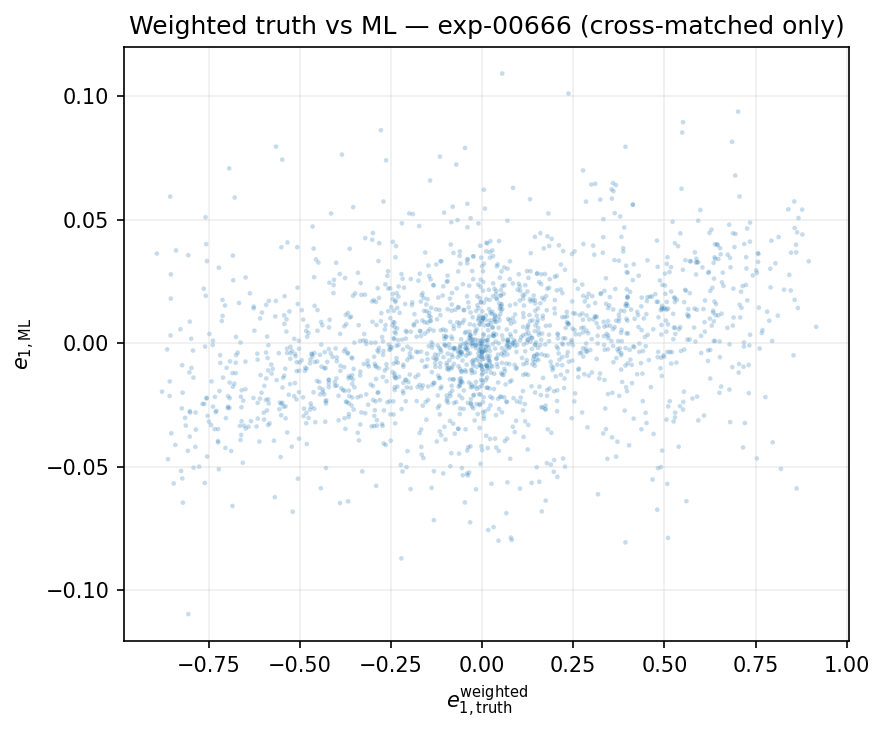

prepare_q_images: 100%|██████████| 3/3 [00:00<00:00, 6192.38it/s]

  [ml_shape_measure timing]  n_stamps=3
    noise prep:  0.00s
    prepare_q:   0.03s  ← CPU multi-process (anacal FFT)
    dtype cast:  0.00s
    shape_meas:  0.02s  ← GPU forward+backward + response loop
    ─────────────────────────────
    total:       0.05s



prepare_q_images: 100%|██████████| 3/3 [00:00<00:00, 4674.19it/s]


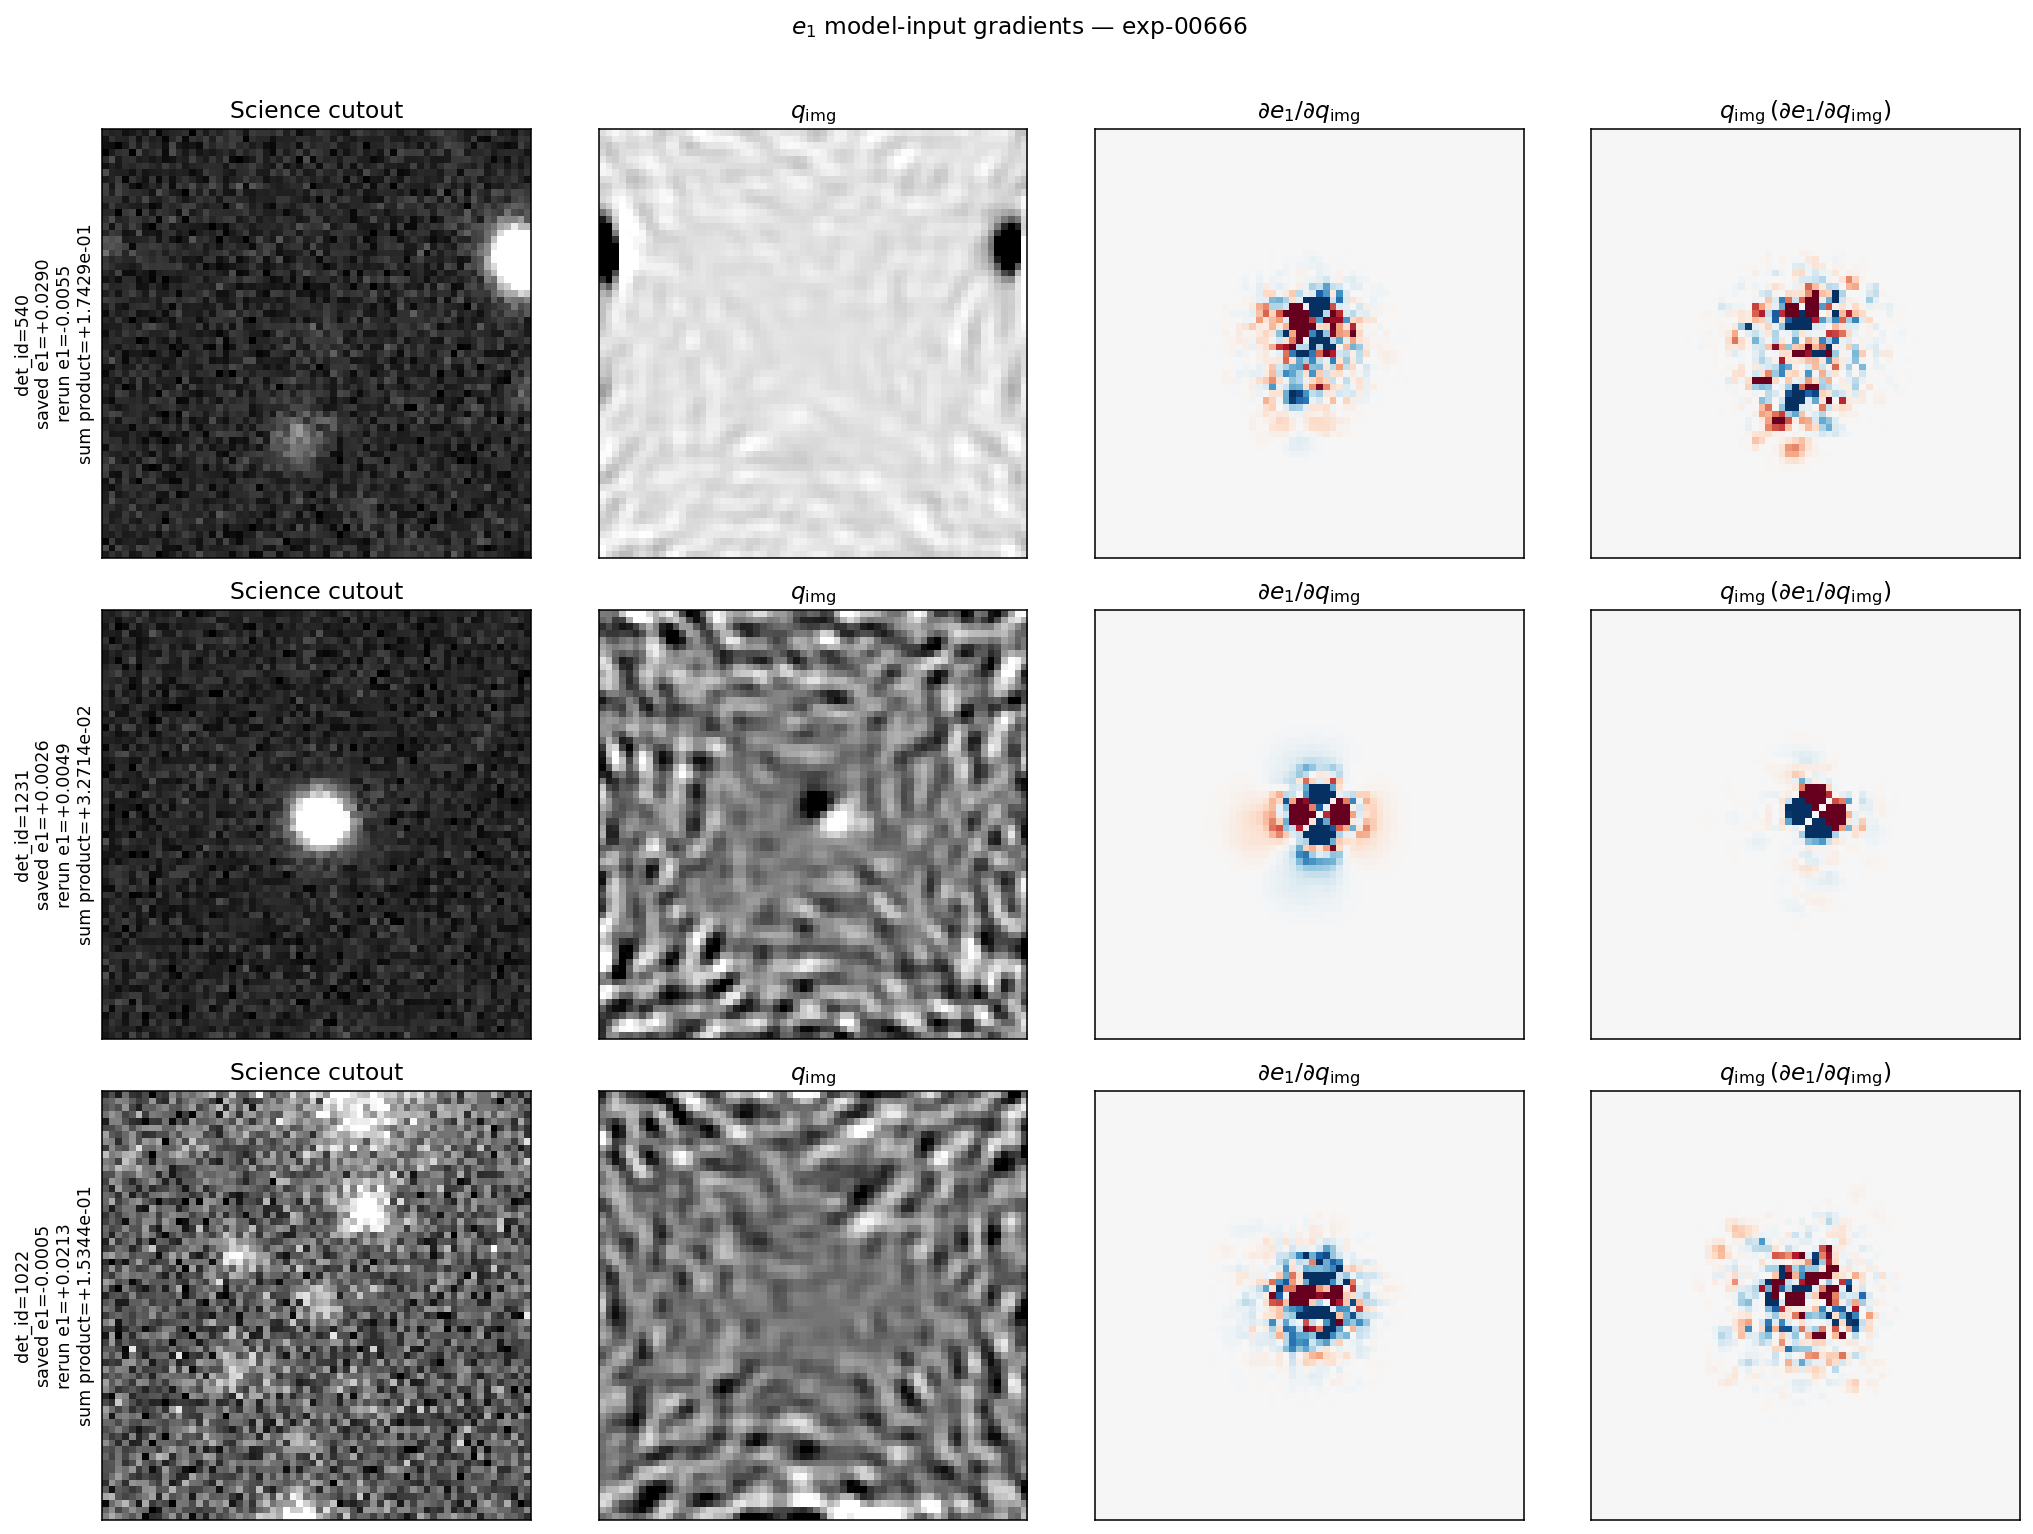

In [10]:
# ===== Weighted truth vs ML + cutout/q_img/model-gradient inspection =====
import numpy as np
import matplotlib.pyplot as plt
import torch
from src.anacal.batch_calibration import Calibrator
from src.anacal.detection_ml_pipeline import cut_stamps_from_large
from src.blending.ml_shape_measurement import ml_shape_measure
from src.architecture.forward8_CNN import Forward8_fixW_CNN

SELECT_IDS = [540, 1231, 1022]  # cat["det_id"], not catalog row
STAMP_SIZE = 64
MODEL_PATH = "./models/F8_fpfs_l5c32r01_50ep.pth"
PSF_PATH = "./logs/blended_test_psf.npy"
PIXEL_SCALE = 0.2
PSF_FWHM = 0.85

# ===== 1. Scatter: only e1 (cross-matched detections only) =====
x = np.asarray(cat["truth_e1_weighted"], float)
y = np.asarray(cat["ml_e1"], float)
matched = np.asarray(det_matched, bool)   # from the cross-match cell: True if within MATCH_RADIUS of a truth
good = np.isfinite(x) & np.isfinite(y) & matched

print(f"Scatter: {good.sum():,} / {len(cat):,} catalog rows are cross-matched")
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax.scatter(x[good], y[good], s=5, alpha=0.25, edgecolors="none", rasterized=True)
ax.set(xlabel=r"$e_{1,\rm truth}^{\rm weighted}$", ylabel=r"$e_{1,\rm ML}$",
       title=f"Weighted truth vs ML — exp-{EXP_IDX:05d} (cross-matched only)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ===== 2. Find selected catalog rows =====
rows = []
for det_id in SELECT_IDS:
    found = np.flatnonzero(cat["det_id"] == det_id)
    if len(found): rows.append(int(found[0]))
    else: print(f"det_id={det_id} not found")
if not rows: raise ValueError("None of SELECT_IDS were found")

# ===== 3. Recreate science/noise stamps exactly as in the pipeline =====
det_dtype = [("det_id", "i4"), ("y", "f8"), ("x", "f8")]
det_sel = np.empty(len(rows), dtype=det_dtype)
det_sel["det_id"] = cat["det_id"][rows]
det_sel["y"] = cat["y"][rows]
det_sel["x"] = cat["x"][rows]
stamps, _ = cut_stamps_from_large(image, det_sel, stamp_size=STAMP_SIZE)

fits_path = f"{BLENDED_DIR}/{SIM_MODE}/exp-i-{EXP_IDX:05d}.fits"
with fits.open(fits_path, memmap=False) as hdul:
    variance = np.asarray(hdul[3].data, float)
valid_var = variance[np.isfinite(variance) & (variance > 0)]
noise_sigma = float(np.sqrt(np.median(valid_var))) if len(valid_var) else 0.3
rng = np.random.default_rng(20020620 + EXP_IDX)
noise_canvas = rng.normal(0, noise_sigma, image.shape).astype(np.float32)
noise_stamps, _ = cut_stamps_from_large(noise_canvas, det_sel, stamp_size=STAMP_SIZE)

# ===== 4. Load the same PSF/model/calibrator =====
device = "cuda" if torch.cuda.is_available() else "cpu"
psf = np.load(PSF_PATH).astype(np.float64)
if psf.ndim == 3: psf = psf[0]
if psf.shape[0] % 2 or psf.shape[1] % 2: psf = psf[1:, 1:]

model = Forward8_fixW_CNN(num_layers=5, base_channels=32, res_factor=0.1,
                          nl_sigma=4, gw_sigma=4).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
calibrator = Calibrator(model, device=device, dtype="float32")

# Capture the actual q_img passed to model.forward()
captured = []
hook = model.register_forward_pre_hook(
    lambda module, inputs: captured.append(inputs[0].detach().cpu().clone())
)
ml_shape_new, _ = ml_shape_measure(
    stamps=stamps, psf_image=psf, calibrator=calibrator,
    pixel_scale=PIXEL_SCALE, psf_fwhm=PSF_FWHM,
    noise_arrays=noise_stamps, n_workers=1, dtype="float32",
    ml_batch_size=len(rows), seed=20020620 + EXP_IDX
)
hook.remove()
if not captured: raise RuntimeError("No model input was captured")

n_stamps = stamps.shape[0]
sigma_arcsec = 0.38
psfs = np.tile(psf, (n_stamps, 1, 1))

# Prepare Q-images
q_imgs = prepare_q_images(
    images=stamps,
    psfs=psfs,
    noises=noise_stamps,
    cat=None,                     # no subpixel offsets needed
    pixel_scale=0.2,
    sigma_arcsec=sigma_arcsec,
    flim=10,
    workers=2,
)


# ===== 5. Calculate ∂e1/∂q_img =====

def output_tensor(out):
    if torch.is_tensor(out): return out
    if isinstance(out, (tuple, list)): return next(v for v in out if torch.is_tensor(v))
    if isinstance(out, dict): return next(v for v in out.values() if torch.is_tensor(v))
    raise TypeError(f"Unsupported model output: {type(out)}")

def image_plane(a):
    a = np.squeeze(np.asarray(a))
    if a.ndim == 3: a = a[0]
    if a.ndim != 2: raise ValueError(f"Cannot display array with shape {a.shape}")
    return a
    
grad_e1, pred_e1 = [], []
for j in range(len(rows)):
    q = torch.tensor(q_imgs[j:j+1,0:1], dtype=torch.float32).to(device).clone().requires_grad_(True)
    out = model(q).reshape(1, -1)
    pred_e1.append(float(out[0, 0].detach().cpu()))
    grad = torch.autograd.grad(out[0, 0], q)[0][0]
    grad_e1.append(grad.detach().cpu().numpy())
pred_e1 = np.asarray(pred_e1)

# ===== 6. Cutout | q_img | de1/dq_img | pixel-wise product =====
fig, axes = plt.subplots(len(rows), 4, figsize=(15, 3.6*len(rows)),
                         dpi=140, squeeze=False)

for j, row in enumerate(rows):
    stamp_plot = image_plane(stamps[j])
    q_plot = image_plane(q_imgs[j,1])
    grad_plot = image_plane(grad_e1[j])
    product_plot = q_plot * grad_plot

    panels = [stamp_plot, q_plot, grad_plot, product_plot]
    titles = ["Science cutout", r"$q_{\rm img}$",
              r"$\partial e_1/\partial q_{\rm img}$",
              r"$q_{\rm img}\,(\partial e_1/\partial q_{\rm img})$"]

    for k, (panel, title) in enumerate(zip(panels, titles)):
        ax = axes[j, k]
        if k < 2:
            lo, hi = np.nanpercentile(panel, [1, 99])
            ax.imshow(panel, origin="lower", cmap="gray", vmin=lo, vmax=hi)
        else:
            vmax = np.nanpercentile(np.abs(panel), 99)
            if not np.isfinite(vmax) or vmax == 0: vmax = 1
            ax.imshow(panel, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])

    axes[j, 0].set_ylabel(
        f"det_id={cat['det_id'][row]}\n"
        f"saved e1={cat['ml_e1'][row]:+.4f}\n"
        f"rerun e1={pred_e1[j]:+.4f}\n"
        f"sum product={np.nansum(product_plot):+.4e}", fontsize=9)

plt.suptitle(f"$e_1$ model-input gradients — exp-{EXP_IDX:05d}", y=1.01)
plt.tight_layout()
plt.show()

# Noiseless Test

In [2]:
from pathlib import Path

import numpy as np
from astropy.io import fits
from src.anacal.batch_calibration import prepare_q_images


TEMP_DIR = Path("./output/sim80_temp/constant_shear_random/g1/shear02")
EXP_IDX = 0  # 根据实际文件编号修改

# mode0 : g1 = -0.02
# mode80: g1 =  0
# mode40: g1 = +0.02
SIM_MODES = {
    "g1_m002": {
        "mode": "mode0",
        "g1": -0.02,
    },
    "g1_0": {
        "mode": "mode80",
        "g1": 0.0,
    },
    "g1_p002": {
        "mode": "mode40",
        "g1": 0.02,
    },
}

sim_data = {}

PSF_PATH = "./logs/blended_test_psf.npy"
psf = np.load(PSF_PATH).astype(np.float64)

if psf.ndim == 3:
    psf = psf[0]

# 保持 PSF 尺寸为偶数
if psf.shape[0] % 2:
    psf = psf[1:, :]
if psf.shape[1] % 2:
    psf = psf[:, 1:]

for label, config in SIM_MODES.items():
    mode = config["mode"]

    fits_path = TEMP_DIR / mode / f"exp-i-{EXP_IDX:05d}.fits"
    truth_path = TEMP_DIR / mode / f"truth-{EXP_IDX:05d}.fits"

    for path in (fits_path, truth_path):
        if not path.exists():
            raise FileNotFoundError(f"File not found: {path}")

    # Read simulated exposure
    with fits.open(fits_path, memmap=False) as hdul:
        image = np.asarray(
            hdul[1].data,
            dtype=np.float64,
        ).copy()

        variance_map = np.asarray(
            hdul[3].data,
            dtype=np.float64,
        ).copy()

    # Read truth catalog
    with fits.open(truth_path, memmap=False) as hdul:
        truth = hdul[1].data.copy()

    sim_data[label] = {
        "mode": mode,
        "g1": config["g1"],
        "image": image,
        "variance_map": variance_map,
        "truth": truth,
        "fits_path": fits_path,
        "truth_path": truth_path,
    }

    print(
        f"{label}: mode={mode}, "
        f"g1={config['g1']:+.3f}, "
        f"image={image.shape}, "
        f"truth={len(truth):,}"
    )

g1_m002: mode=mode0, g1=-0.020, image=(1500, 1500), truth=62,619
g1_0: mode=mode80, g1=+0.000, image=(1500, 1500), truth=62,619
g1_p002: mode=mode40, g1=+0.020, image=(1500, 1500), truth=62,619


In [22]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u


PIXEL_SCALE = 0.2
STAMP_SIZE = 64

X_OFFSET = 1500
Y_OFFSET = 1500

LABEL_M = "g1_m002"    # mode0,  g1 = -0.02
LABEL_0 = "g1_0"       # mode80, g1 =  0
LABEL_P = "g1_p002"    # mode40, g1 = +0.02


# ============================================================
# 0. 读取三种 shear 的 image / variance / truth
# ============================================================

image_gm = sim_data[LABEL_M]["image"]
variance_gm = sim_data[LABEL_M]["variance_map"]
truth_gm = sim_data[LABEL_M]["truth"]

image_g0 = sim_data[LABEL_0]["image"]
variance_g0 = sim_data[LABEL_0]["variance_map"]
truth_g0 = sim_data[LABEL_0]["truth"]

image_gp = sim_data[LABEL_P]["image"]
variance_gp = sim_data[LABEL_P]["variance_map"]
truth_gp = sim_data[LABEL_P]["truth"]


# ============================================================
# 1. 两个 catalog 之间的 mutual-nearest matching
# ============================================================

def mutual_match_by_prelensed_coord(
    truth_ref,
    truth_target,
    tolerance_arcsec=1.0e-4,
):
    """
    使用 prelensed_ra/prelensed_dec，将 target catalog 匹配到 ref catalog。

    返回
    ----
    match : structured ndarray
        row_ref        : truth_ref 中的行号
        row_target     : truth_target 中的行号
        index_ref      : truth_ref["indices"]
        index_target   : truth_target["indices"]
        sep_arcsec     : 两个 prelensed 坐标之间的角距离
    """
    required = {"prelensed_ra", "prelensed_dec", "indices"}

    for label, truth in [
        ("truth_ref", truth_ref),
        ("truth_target", truth_target),
    ]:
        names = set(truth.dtype.names or [])
        missing = required.difference(names)

        if missing:
            raise KeyError(f"{label} 缺少字段: {sorted(missing)}")

    ra_ref = np.asarray(truth_ref["prelensed_ra"], dtype=float)
    dec_ref = np.asarray(truth_ref["prelensed_dec"], dtype=float)

    ra_target = np.asarray(
        truth_target["prelensed_ra"],
        dtype=float,
    )
    dec_target = np.asarray(
        truth_target["prelensed_dec"],
        dtype=float,
    )

    valid_ref = np.isfinite(ra_ref) & np.isfinite(dec_ref)
    valid_target = np.isfinite(ra_target) & np.isfinite(dec_target)

    rows_ref_valid = np.flatnonzero(valid_ref)
    rows_target_valid = np.flatnonzero(valid_target)

    if len(rows_ref_valid) == 0:
        raise ValueError("truth_ref 中没有有效的 prelensed 坐标")

    if len(rows_target_valid) == 0:
        raise ValueError("truth_target 中没有有效的 prelensed 坐标")

    coord_ref = SkyCoord(
        ra=ra_ref[valid_ref] * u.deg,
        dec=dec_ref[valid_ref] * u.deg,
        frame="icrs",
    )

    coord_target = SkyCoord(
        ra=ra_target[valid_target] * u.deg,
        dec=dec_target[valid_target] * u.deg,
        frame="icrs",
    )

    # ref -> target
    nearest_target, sep_ref_target, _ = (
        coord_ref.match_to_catalog_sky(coord_target)
    )

    # target -> ref，用于 mutual-nearest 检查
    nearest_ref, _, _ = coord_target.match_to_catalog_sky(coord_ref)

    local_ref = np.arange(len(coord_ref))

    mutual = nearest_ref[nearest_target] == local_ref
    close = sep_ref_target.arcsec <= tolerance_arcsec
    keep = mutual & close

    row_ref = rows_ref_valid[local_ref[keep]]
    row_target = rows_target_valid[nearest_target[keep]]
    separation = sep_ref_target.arcsec[keep]

    match_dtype = [
        ("row_ref", "i8"),
        ("row_target", "i8"),
        ("index_ref", "i8"),
        ("index_target", "i8"),
        ("sep_arcsec", "f8"),
    ]

    match = np.empty(len(row_ref), dtype=match_dtype)

    match["row_ref"] = row_ref
    match["row_target"] = row_target
    match["index_ref"] = np.asarray(
        truth_ref["indices"][row_ref],
        dtype=np.int64,
    )
    match["index_target"] = np.asarray(
        truth_target["indices"][row_target],
        dtype=np.int64,
    )
    match["sep_arcsec"] = separation

    return match


# ============================================================
# 2. 以 g1=0 为基准，分别匹配负、正 shear
# ============================================================

match_0m = mutual_match_by_prelensed_coord(
    truth_ref=truth_g0,
    truth_target=truth_gm,
    tolerance_arcsec=1.0e-4,
)

match_0p = mutual_match_by_prelensed_coord(
    truth_ref=truth_g0,
    truth_target=truth_gp,
    tolerance_arcsec=1.0e-4,
)

print(f"g1=-0.02 truth objects : {len(truth_gm):,}")
print(f"g1= 0.00 truth objects : {len(truth_g0):,}")
print(f"g1=+0.02 truth objects : {len(truth_gp):,}")

print(f"0 <-> -0.02 matches    : {len(match_0m):,}")
print(f"0 <-> +0.02 matches    : {len(match_0p):,}")


# ============================================================
# 3. 合并为三重匹配
# ============================================================

# 找到在两个匹配结果中都出现的 g=0 catalog 行号
common_row0, loc_0m, loc_0p = np.intersect1d(
    match_0m["row_ref"],
    match_0p["row_ref"],
    assume_unique=True,
    return_indices=True,
)

triplet_dtype = [
    ("pair_id", "i8"),
    ("rowm", "i8"),
    ("row0", "i8"),
    ("rowp", "i8"),
    ("indexm", "i8"),
    ("index0", "i8"),
    ("indexp", "i8"),
    ("sep_0m_arcsec", "f8"),
    ("sep_0p_arcsec", "f8"),
]

pairs = np.empty(len(common_row0), dtype=triplet_dtype)

pairs["pair_id"] = np.arange(len(common_row0))
pairs["rowm"] = match_0m["row_target"][loc_0m]
pairs["row0"] = common_row0
pairs["rowp"] = match_0p["row_target"][loc_0p]

pairs["indexm"] = np.asarray(
    truth_gm["indices"][pairs["rowm"]],
    dtype=np.int64,
)
pairs["index0"] = np.asarray(
    truth_g0["indices"][pairs["row0"]],
    dtype=np.int64,
)
pairs["indexp"] = np.asarray(
    truth_gp["indices"][pairs["rowp"]],
    dtype=np.int64,
)

pairs["sep_0m_arcsec"] = match_0m["sep_arcsec"][loc_0m]
pairs["sep_0p_arcsec"] = match_0p["sep_arcsec"][loc_0p]


# ============================================================
# 4. 匹配结果检查
# ============================================================

print(f"three-way matched pairs: {len(pairs):,}")

if len(pairs):
    print(
        "maximum 0/- separation:",
        f"{pairs['sep_0m_arcsec'].max():.3e} arcsec",
    )
    print(
        "maximum 0/+ separation:",
        f"{pairs['sep_0p_arcsec'].max():.3e} arcsec",
    )

    print(
        "median 0/- separation :",
        f"{np.median(pairs['sep_0m_arcsec']):.3e} arcsec",
    )
    print(
        "median 0/+ separation :",
        f"{np.median(pairs['sep_0p_arcsec']):.3e} arcsec",
    )

    same_all_indices = (
        (pairs["indexm"] == pairs["index0"])
        & (pairs["index0"] == pairs["indexp"])
    )

    print(
        "same indices in all three:",
        f"{np.mean(same_all_indices):.6f}",
    )

g1=-0.02 truth objects : 62,619
g1= 0.00 truth objects : 62,619
g1=+0.02 truth objects : 62,619
0 <-> -0.02 matches    : 62,619
0 <-> +0.02 matches    : 62,619
three-way matched pairs: 62,619
maximum 0/- separation: 0.000e+00 arcsec
maximum 0/+ separation: 0.000e+00 arcsec
median 0/- separation : 0.000e+00 arcsec
median 0/+ separation : 0.000e+00 arcsec
same indices in all three: 1.000000


In [23]:
# ============================================================
# 2. truth dx/dy -> 每张 exposure 中的像素坐标
# ============================================================

def truth_to_pixel(truth, image_shape):
    """
    根据当前模拟的 truth["dx"], truth["dy"] 得到图像像素位置。

    返回
    ----
    x, y : ndarray
        浮点像素坐标。
    """
    ny, nx = image_shape

    x = (
        nx / 2
        + np.asarray(truth["dx"], dtype=float) / PIXEL_SCALE
        + X_OFFSET
    )
    y = (
        ny / 2
        + np.asarray(truth["dy"], dtype=float) / PIXEL_SCALE
        + Y_OFFSET
    )

    return x, y


def cut_one_stamp(image, x, y, stamp_size=64):
    """
    按与整数像素对齐的方式切出固定大小 cutout。

    对于偶数 stamp_size，中心像素范围为：
        [floor(x)-stamp_size//2, floor(x)+stamp_size//2)

    如果 cutout 越过图像边界则返回 None。
    """
    if stamp_size % 2 != 0:
        raise ValueError("这里要求 stamp_size 为偶数")

    ny, nx = image.shape
    half = stamp_size // 2

    x_center = int(np.floor(x))
    y_center = int(np.floor(y))

    x0 = x_center - half
    x1 = x0 + stamp_size
    y0 = y_center - half
    y1 = y0 + stamp_size

    if x0 < 0 or y0 < 0 or x1 > nx or y1 > ny:
        return None

    return np.asarray(image[y0:y1, x0:x1]).copy()

xm_all, ym_all = truth_to_pixel(truth_gm, image_gm.shape)
x0_all, y0_all = truth_to_pixel(truth_g0, image_g0.shape)
xp_all, yp_all = truth_to_pixel(truth_gp, image_gp.shape)

inside_m = (
    (xm_all >= 0) & (xm_all < 1500)
    & (ym_all >= 0) & (ym_all < 1500)
)

inside_0 = (
    (x0_all >= 0) & (x0_all < 1500)
    & (y0_all >= 0) & (y0_all < 1500)
)

inside_p = (
    (xp_all >= 0) & (xp_all < 1500)
    & (yp_all >= 0) & (yp_all < 1500)
)


# ============================================================
# i-band magnitude cut: i_ab <= 23
# ============================================================

I_AB_LIMIT = 25.0

for label, truth in [
    ("truth_gm", truth_gm),
    ("truth_g0", truth_g0),
    ("truth_gp", truth_gp),
]:
    if "i_ab" not in (truth.dtype.names or ()):
        raise KeyError(f"{label} 中没有 i_ab 字段")

i_ab_m = np.asarray(truth_gm["i_ab"], dtype=float)
i_ab_0 = np.asarray(truth_g0["i_ab"], dtype=float)
i_ab_p = np.asarray(truth_gp["i_ab"], dtype=float)

bright_m = np.isfinite(i_ab_m) & (i_ab_m <= I_AB_LIMIT)
bright_0 = np.isfinite(i_ab_0) & (i_ab_0 <= I_AB_LIMIT)
bright_p = np.isfinite(i_ab_p) & (i_ab_p <= I_AB_LIMIT)


# 三张图中都位于图像内，并且三个 catalog 中均满足亮度限制
pair_keep = (
    inside_m[pairs["rowm"]]
    & inside_0[pairs["row0"]]
    & inside_p[pairs["rowp"]]
    & bright_m[pairs["rowm"]]
    & bright_0[pairs["row0"]]
    & bright_p[pairs["rowp"]]
)

n_before = len(pairs)

pairs = pairs[pair_keep].copy()
pairs["pair_id"] = np.arange(len(pairs))

print(f"Three-way pairs before cuts : {n_before:,}")
print(
    f"Inside all images and i_ab <= {I_AB_LIMIT:g}: "
    f"{len(pairs):,}"
)

# ============================================================
# 3. 按指定对象提取成对 cutout
# ============================================================

def get_paired_cutout(
    pair_id=None,
    truth_index=None,
    stamp_size=64,
):
    """
    指定 pair_id 或 truth["indices"]，返回三个 shear 下的匹配 cutout。

    返回顺序
    --------
    stamp_gm : g1 = -0.02
    stamp_g0 : g1 =  0
    stamp_gp : g1 = +0.02
    info     : 三重匹配及像素坐标信息

    Parameters
    ----------
    pair_id : int, optional
        pairs 数组中的三重匹配编号。
    truth_index : int, optional
        任意一个 truth catalog 中的 indices 字段值。
    stamp_size : int, default=64
        cutout 边长，要求为偶数。
    """
    if (pair_id is None) == (truth_index is None):
        raise ValueError(
            "必须且只能指定 pair_id 或 truth_index 中的一个"
        )

    if stamp_size <= 0 or stamp_size % 2 != 0:
        raise ValueError(
            f"stamp_size 必须为正偶数，当前值为 {stamp_size}"
        )

    # ============================================================
    # 1. 找到对应的三重匹配
    # ============================================================

    if pair_id is not None:
        selected = np.flatnonzero(
            pairs["pair_id"] == pair_id
        )
        selection_name = f"pair_id={pair_id}"
    else:
        selected = np.flatnonzero(
            (pairs["indexm"] == truth_index)
            | (pairs["index0"] == truth_index)
            | (pairs["indexp"] == truth_index)
        )
        selection_name = f"truth_index={truth_index}"

    if len(selected) == 0:
        raise KeyError(f"没有找到 {selection_name}")

    if len(selected) > 1:
        matched_pair_ids = pairs["pair_id"][selected]

        raise RuntimeError(
            f"{selection_name} 对应 {len(selected)} 个三重匹配，"
            f"匹配不是唯一的；pair_id={matched_pair_ids.tolist()}"
        )

    pair = pairs[selected[0]]

    rowm = int(pair["rowm"])
    row0 = int(pair["row0"])
    rowp = int(pair["rowp"])

    # ============================================================
    # 2. 获取三个 shear 下的像素坐标
    # ============================================================

    xm = float(xm_all[rowm])
    ym = float(ym_all[rowm])

    x0 = float(x0_all[row0])
    y0 = float(y0_all[row0])

    xp = float(xp_all[rowp])
    yp = float(yp_all[rowp])

    coordinates = {
        LABEL_M: (xm, ym),
        LABEL_0: (x0, y0),
        LABEL_P: (xp, yp),
    }

    for label, (x, y) in coordinates.items():
        if not np.isfinite(x) or not np.isfinite(y):
            raise ValueError(
                f"{label} 的像素坐标不是有限值: x={x}, y={y}"
            )

    # ============================================================
    # 3. 切出三个 cutout
    # ============================================================

    stamp_gm = cut_one_stamp(
        image_gm,
        x=xm,
        y=ym,
        stamp_size=stamp_size,
    )

    stamp_g0 = cut_one_stamp(
        image_g0,
        x=x0,
        y=y0,
        stamp_size=stamp_size,
    )

    stamp_gp = cut_one_stamp(
        image_gp,
        x=xp,
        y=yp,
        stamp_size=stamp_size,
    )

    stamps = {
        LABEL_M: (stamp_gm, xm, ym),
        LABEL_0: (stamp_g0, x0, y0),
        LABEL_P: (stamp_gp, xp, yp),
    }

    for label, (stamp, x, y) in stamps.items():
        if stamp is None:
            raise ValueError(
                f"{label} 中的对象距离图像边界过近，无法切出 "
                f"{stamp_size}×{stamp_size} cutout: "
                f"x={x:.3f}, y={y:.3f}"
            )

        if stamp.shape != (stamp_size, stamp_size):
            raise RuntimeError(
                f"{label} cutout 尺寸异常: "
                f"得到 {stamp.shape}，预期 "
                f"({stamp_size}, {stamp_size})"
            )

    # ============================================================
    # 4. 保存匹配、坐标和 subpixel offset 信息
    # ============================================================

    info = {
        "pair_id": int(pair["pair_id"]),

        "rowm": rowm,
        "row0": row0,
        "rowp": rowp,

        "indexm": int(pair["indexm"]),
        "index0": int(pair["index0"]),
        "indexp": int(pair["indexp"]),

        "sep_0m_arcsec": float(pair["sep_0m_arcsec"]),
        "sep_0p_arcsec": float(pair["sep_0p_arcsec"]),

        "xm": xm,
        "ym": ym,
        "x0": x0,
        "y0": y0,
        "xp": xp,
        "yp": yp,

        "fractional_offset_m": (
            float(xm - np.floor(xm)),
            float(ym - np.floor(ym)),
        ),
        "fractional_offset_0": (
            float(x0 - np.floor(x0)),
            float(y0 - np.floor(y0)),
        ),
        "fractional_offset_p": (
            float(xp - np.floor(xp)),
            float(yp - np.floor(yp)),
        ),

        # 相对于零 shear cutout 的 subpixel-offset 变化
        "delta_fractional_offset_m0": (
            float(
                (xm - np.floor(xm))
                - (x0 - np.floor(x0))
            ),
            float(
                (ym - np.floor(ym))
                - (y0 - np.floor(y0))
            ),
        ),
        "delta_fractional_offset_p0": (
            float(
                (xp - np.floor(xp))
                - (x0 - np.floor(x0))
            ),
            float(
                (yp - np.floor(yp))
                - (y0 - np.floor(y0))
            ),
        ),
    }

    return stamp_gm, stamp_g0, stamp_gp, info

Three-way pairs before cuts : 62,619
Inside all images and i_ab <= 25: 930


prepare_q_images: 100%|██████████| 3/3 [00:00<00:00, 1513.10it/s]


images shape : (3, 64, 64)
q_imgs shape : (3, 5, 64, 64)


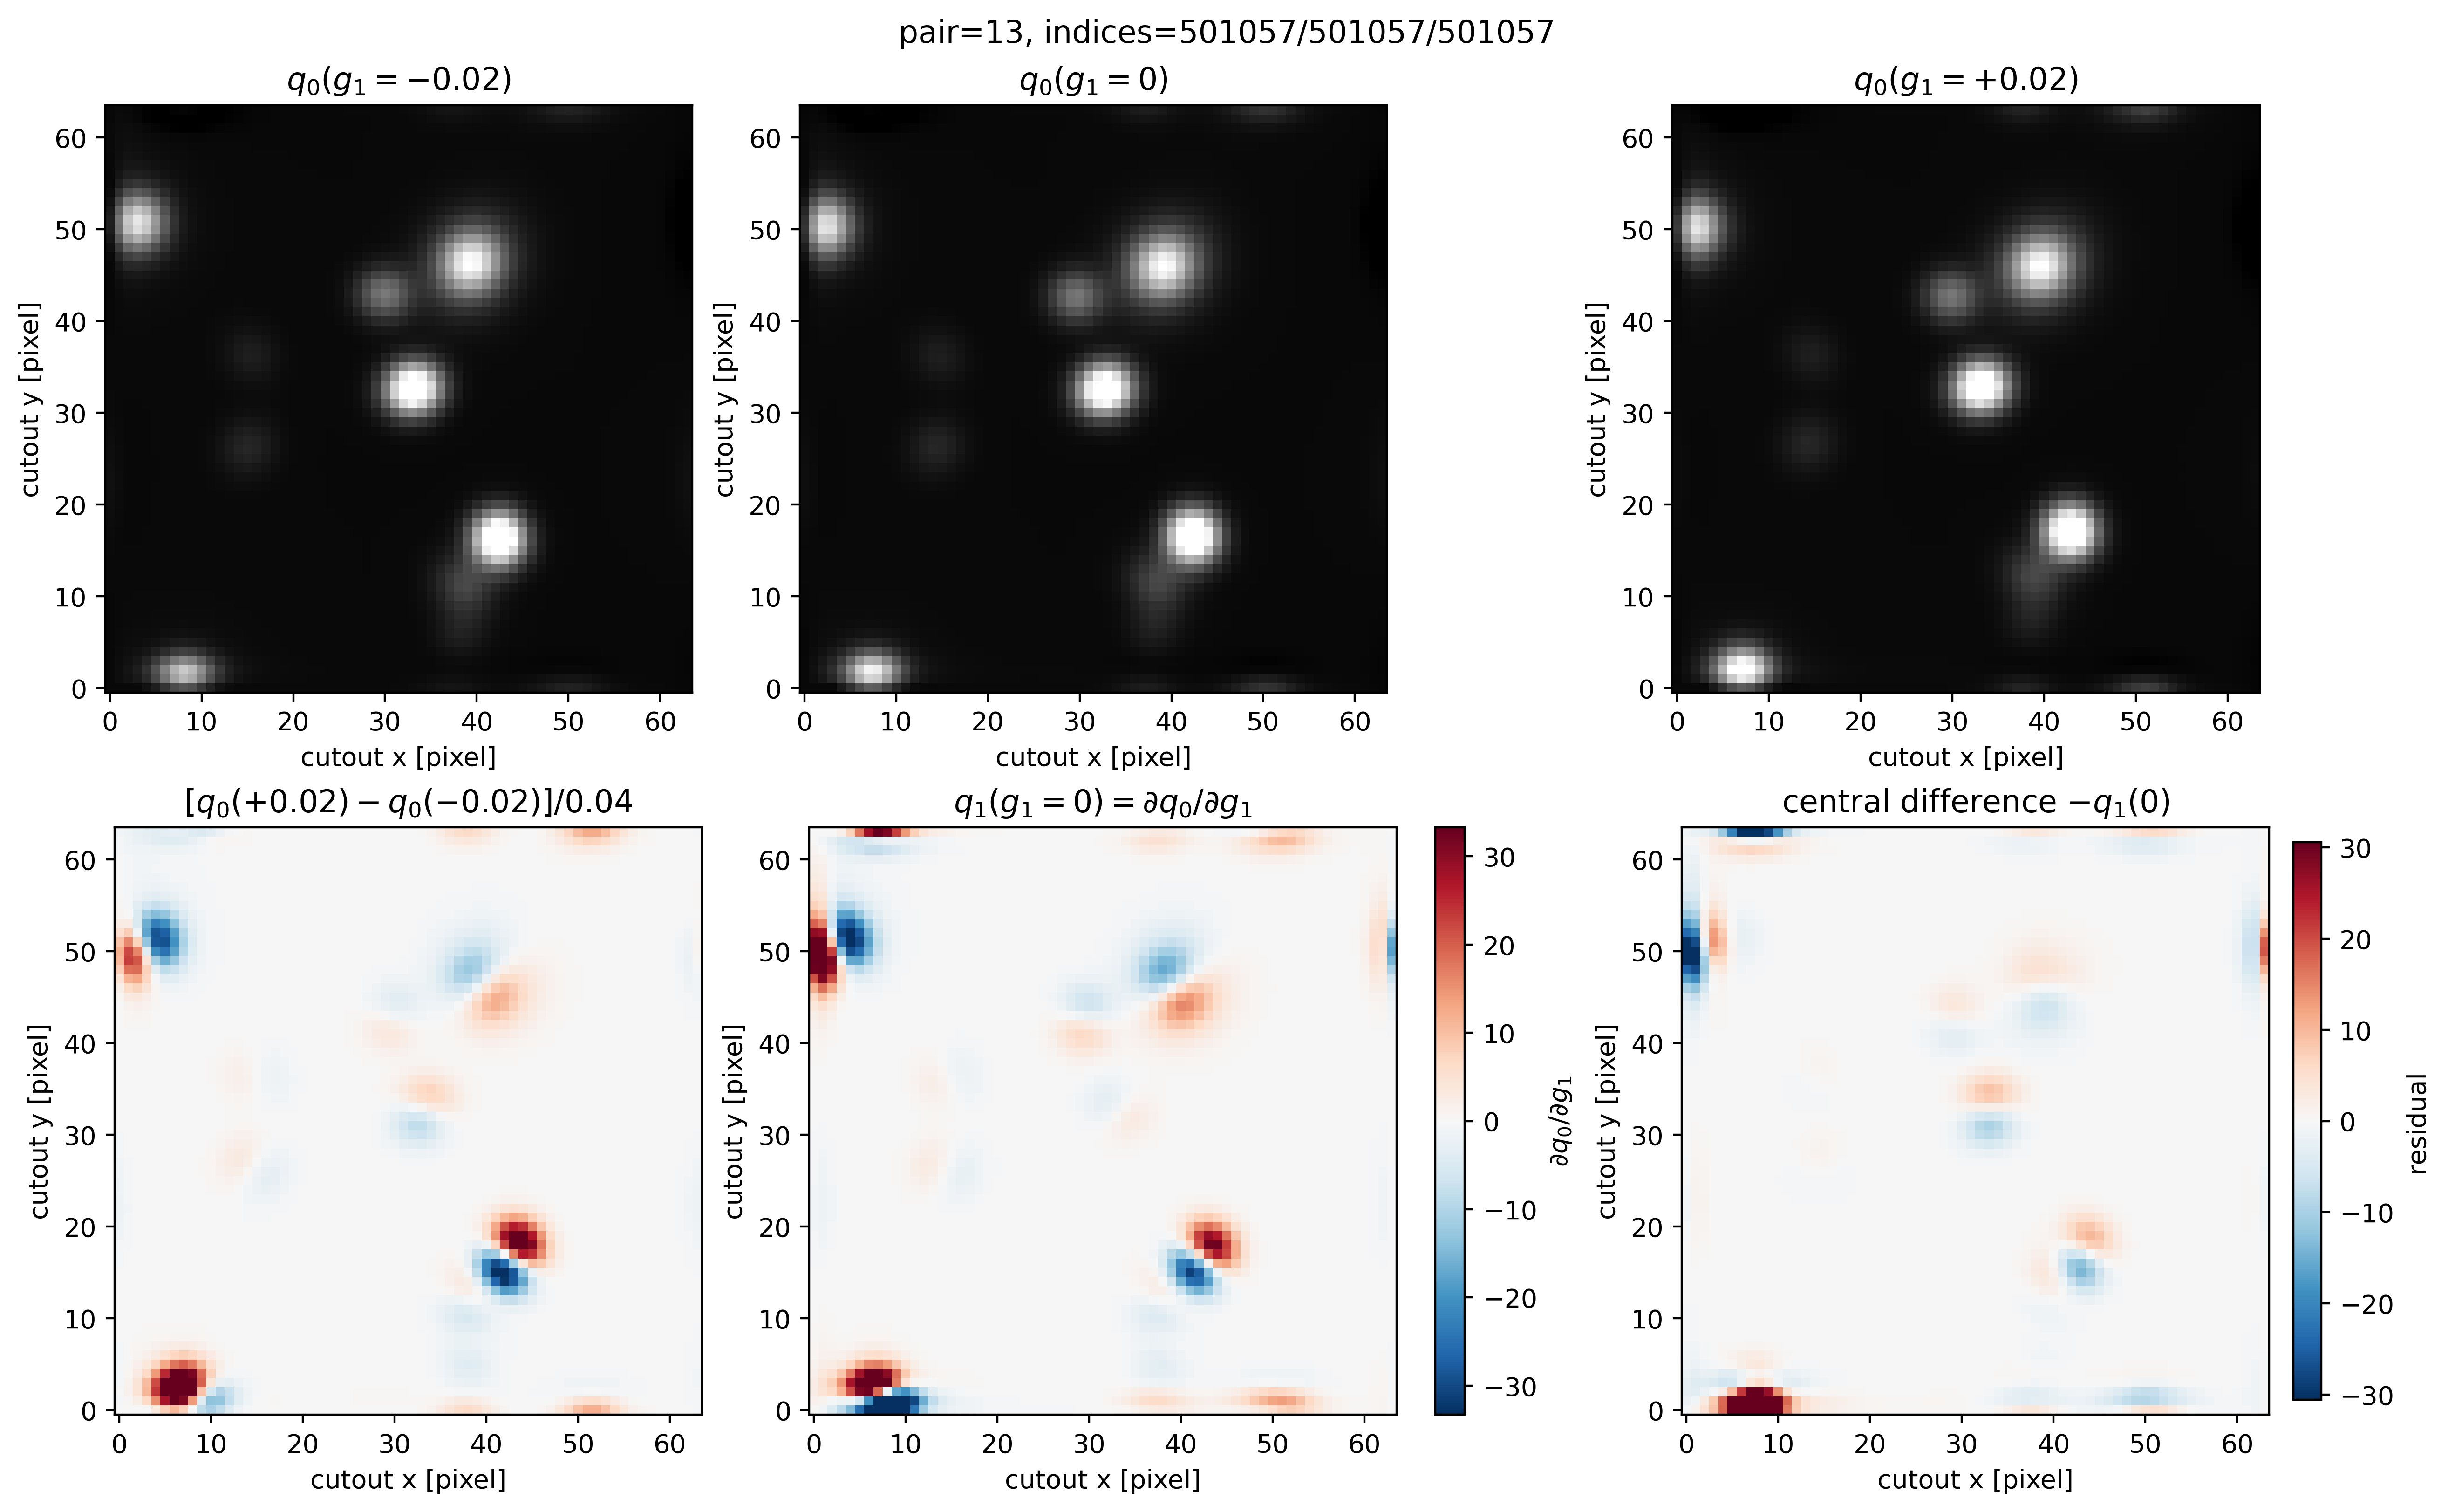

In [30]:
stamp_gm, stamp_g0, stamp_gp, info = get_paired_cutout(
    pair_id=13,
    stamp_size=64,
)

DELTA_G1 = 0.02


# ============================================================
# 1. 同时生成三种 shear 的 q_imgs
# ============================================================

images = np.stack(
    [stamp_gm, stamp_g0, stamp_gp],
    axis=0,
).astype(np.float64)  # (3, H, W)

psf_array = np.asarray(psf, dtype=np.float64)

if psf_array.ndim == 2:
    psfs = np.repeat(psf_array[None, :, :], 3, axis=0)
elif psf_array.ndim == 3 and psf_array.shape[0] == 1:
    psfs = np.repeat(psf_array, 3, axis=0)
elif psf_array.ndim == 3 and psf_array.shape[0] == 3:
    psfs = psf_array
else:
    raise ValueError(f"Unexpected PSF shape: {psf_array.shape}")

q_imgs = prepare_q_images(
    images=images,
    psfs=psfs,
    noises=np.zeros_like(images),
    cat=None,  # 保留每张 cutout 自己的 subpixel offset
    pixel_scale=0.2,
    sigma_arcsec=0.38,
    flim=10,
    workers=1,
)

q_imgs = np.asarray(q_imgs)

print("images shape :", images.shape)
print("q_imgs shape :", q_imgs.shape)

assert q_imgs.shape[:2] == (3, 5)


# 排列顺序：负 shear、零 shear、正 shear
q0_gm = q_imgs[0, 0]
q0_g0 = q_imgs[1, 0]
q0_gp = q_imgs[2, 0]

# 只使用零 shear 图像的解析 g1 导数
q1_g0 = q_imgs[1, 1]

# 正负 shear 的中心有限差分
q0_central_difference = (
    q0_gp - q0_gm
) / (2.0 * DELTA_G1)

residual = q0_central_difference - q1_g0


# ============================================================
# 2. 显示范围
# ============================================================

def symmetric_limit(*arrays, percentile=99.5):
    values = np.concatenate([
        np.abs(np.asarray(a)[np.isfinite(a)]).ravel()
        for a in arrays
    ])

    limit = np.percentile(values, percentile) if values.size else 1.0

    if not np.isfinite(limit) or limit <= 0:
        limit = 1.0

    return limit


q0_vmin = min(
    np.percentile(q0_gm, 1),
    np.percentile(q0_g0, 1),
    np.percentile(q0_gp, 1),
)
q0_vmax = max(
    np.percentile(q0_gm, 99.5),
    np.percentile(q0_g0, 99.5),
    np.percentile(q0_gp, 99.5),
)

derivative_limit = symmetric_limit(
    q0_central_difference,
    q1_g0,
)

residual_limit = symmetric_limit(
    residual,
    percentile=99.5,
)


# ============================================================
# 3. q_img0 与零 shear q_img1 的比较
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 8),
    dpi=400,
    constrained_layout=True,
)

# 第一行：三种 shear 下的 q_img0
axes[0, 0].imshow(
    q0_gm,
    origin="lower",
    cmap="gray",
    vmin=q0_vmin,
    vmax=q0_vmax,
)
axes[0, 0].set_title(r"$q_0(g_1=-0.02)$")

axes[0, 1].imshow(
    q0_g0,
    origin="lower",
    cmap="gray",
    vmin=q0_vmin,
    vmax=q0_vmax,
)
axes[0, 1].set_title(r"$q_0(g_1=0)$")

axes[0, 2].imshow(
    q0_gp,
    origin="lower",
    cmap="gray",
    vmin=q0_vmin,
    vmax=q0_vmax,
)
axes[0, 2].set_title(r"$q_0(g_1=+0.02)$")


# 第二行：中心差分、零 shear 的 q1、二者残差
im_derivative = axes[1, 0].imshow(
    q0_central_difference,
    origin="lower",
    cmap="RdBu_r",
    vmin=-derivative_limit,
    vmax=derivative_limit,
)
axes[1, 0].set_title(
    r"$[q_0(+0.02)-q_0(-0.02)]/0.04$"
)

axes[1, 1].imshow(
    q1_g0,
    origin="lower",
    cmap="RdBu_r",
    vmin=-derivative_limit,
    vmax=derivative_limit,
)
axes[1, 1].set_title(
    r"$q_1(g_1=0)=\partial q_0/\partial g_1$"
)

im_residual = axes[1, 2].imshow(
    residual,
    origin="lower",
    cmap="RdBu_r",
    vmin=-residual_limit,
    vmax=residual_limit,
)
axes[1, 2].set_title(
    r"central difference $-q_1(0)$"
)

fig.colorbar(
    im_derivative,
    ax=axes[1, :2],
    fraction=0.025,
    pad=0.03,
    label=r"$\partial q_0/\partial g_1$",
)

fig.colorbar(
    im_residual,
    ax=axes[1, 2],
    fraction=0.046,
    pad=0.04,
    label="residual",
)

for ax in axes.ravel():
    ax.set_xlabel("cutout x [pixel]")
    ax.set_ylabel("cutout y [pixel]")

fig.suptitle(
    f"pair={info['pair_id']}, "
    f"indices={info['indexm']}/{info['index0']}/{info['indexp']}",
    fontsize=12,
)

plt.show()